# 🦴 Segmentación de Columna Vertebral con YOLOv8s-seg
## Detección de Escoliosis mediante Ángulo de Cobb y Ensemble T1–T8

**Proyecto Académico — Visión por Computador**

---

### Pipeline completo

```
Máscaras PNG multiclase
        ↓
Conversión a polígonos YOLO (.txt)
        ↓
Fine-tuning YOLOv8s-seg (imgsz=768, augmentations)
        ↓
Búsqueda CONF_AUTO + Clasificación Normal/Escoliosis (Cobb)
        ↓
Dice Score global (píxel a píxel)
        ↓
Modelo especializado T1–T8 (crop superior)
        ↓
Ensemble: modelo completo + especializado
        ↓
Dice por vértebra T1–T12 · L1–L5
        ↓
Visualización con etiquetas vertebrales
```


## 📦 Celda 1: Instalación de dependencias

In [1]:
# Instalar Ultralytics (incluye YOLOv8) y dependencias
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'ultralytics', 'opencv-python', 'matplotlib',
                       'scikit-learn', 'pandas', 'numpy', '-q'])

from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Ultralytics instalado correctamente')
print(f'Dispositivo: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics instalado correctamente
Dispositivo: cuda


## 📂 Celda 2: Carga y división del dataset

Mismo esquema que U-Net: 249 imágenes (71 Normal / 178 Escoliosis), split 70/15/15 estratificado.

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

image_root = '/kaggle/input/datasets/fedysmoreno/images/images/images'
mask_root  = '/kaggle/input/datasets/fedysmoreno/images/labels_clean/labels_clean'

data = []

for label_name in ['Normal', 'Scoliosis']:
    image_folder = os.path.join(image_root, label_name)

    for file in os.listdir(image_folder):
        if not file.endswith('.jpg'):
            continue

        base_name = os.path.splitext(file)[0]
        mask_name = f'LabelMulti_{base_name}.png'

        img_path  = os.path.join(image_folder, file)
        mask_path = os.path.join(mask_root, mask_name)

        if not os.path.exists(mask_path):
            print('Mask no encontrada:', mask_name)
            continue

        label = 0 if label_name == 'Normal' else 1
        data.append({'image': img_path, 'mask': mask_path, 'label': label})

df = pd.DataFrame(data)
print(df.head())
print('Total:', len(df))
print(df['label'].value_counts())

# División estratificada — mismas proporciones que U-Net
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print(f'Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}')

                                               image  \
0  /kaggle/input/datasets/fedysmoreno/images/imag...   
1  /kaggle/input/datasets/fedysmoreno/images/imag...   
2  /kaggle/input/datasets/fedysmoreno/images/imag...   
3  /kaggle/input/datasets/fedysmoreno/images/imag...   
4  /kaggle/input/datasets/fedysmoreno/images/imag...   

                                                mask  label  
0  /kaggle/input/datasets/fedysmoreno/images/labe...      0  
1  /kaggle/input/datasets/fedysmoreno/images/labe...      0  
2  /kaggle/input/datasets/fedysmoreno/images/labe...      0  
3  /kaggle/input/datasets/fedysmoreno/images/labe...      0  
4  /kaggle/input/datasets/fedysmoreno/images/labe...      0  
Total: 248
label
1    177
0     71
Name: count, dtype: int64
Train: 173  |  Val: 37  |  Test: 38


## 🔄 Celda 3: Conversión de máscaras PNG → formato YOLO

### ¿Por qué es necesaria esta conversión?

YOLOv8-seg **no acepta máscaras PNG** como U-Net. Necesita etiquetas en formato `.txt`
donde cada línea representa **una instancia** con su polígono normalizado:

```
class_id  x1 y1  x2 y2  x3 y3 ... xn yn
```

Esto refleja la diferencia fundamental entre segmentación **semántica** (U-Net: un color
por clase en toda la imagen) e **instancia** (YOLO: cada vértebra es un objeto separado
con su propio contorno).

### Mapeo de clases
Las máscaras PNG contienen hasta 24 clases vertebrales (C1–C7, T1–T12, L1–L5).
**Las vértebras cervicales C1–C7 (valores de píxel 1–7) se excluyen** por no ser
relevantes para el análisis de escoliosis toraco-lumbar.
Se conservan 17 clases YOLO (T1–T12, L1–L5).

In [3]:
import cv2
import numpy as np
from pathlib import Path

# ── Nombres de clases vertebrales (C1-C7 excluidas) ──────────────────
# Pixel values en la máscara PNG:
#   0        = fondo (ignorado)
#   1  –  7  = C1-C7  → EXCLUIDAS (no relevantes para escoliosis toraco-lumbar)
#   8  – 19  = T1-T12 → incluidas
#   20 – 24  = L1-L5  → incluidas
CLASS_NAMES = [
    'T1','T2','T3','T4','T5','T6',                # Torácicas  (pixel 8-13  → YOLO 0-5)
    'T7','T8','T9','T10','T11','T12',             # Torácicas  (pixel 14-19 → YOLO 6-11)
    'L1','L2','L3','L4','L5',                     # Lumbares   (pixel 20-24 → YOLO 12-16)
]

# pixel_value → yolo_class_id  (0-indexed)
# Pixel 1-7 (C1-C7) se omiten completamente.
# Pixel 8 → YOLO 0 (T1), pixel 9 → YOLO 1 (T2), ..., pixel 24 → YOLO 16 (L5)
CERVICAL_PIXEL_VALUES = set(range(1, 8))   # C1-C7: excluir
THORACO_LUMBAR_START  = 8                  # primer pixel torácico
PIXEL_TO_YOLO = {
    pv: pv - THORACO_LUMBAR_START
    for pv in range(THORACO_LUMBAR_START, THORACO_LUMBAR_START + len(CLASS_NAMES))
}
N_CLASSES = len(CLASS_NAMES)   # 17


def mask_png_a_yolo_txt(mask_path: str, txt_path: str,
                         min_area: int = 100) -> int:
    """
    Convierte una máscara PNG multiclase al formato de etiquetas YOLO-seg.
    Las vértebras C1-C7 (pixel 1-7) se ignoran automáticamente.

    Para cada vértebra torácica/lumbar:
      1. Binariza la máscara para esa clase.
      2. Encuentra contornos (cv2.findContours).
      3. Toma el contorno más grande (la región principal).
      4. Normaliza las coordenadas al rango [0, 1].
      5. Escribe una línea: class_id x1 y1 x2 y2 ... xn yn

    Parámetros
    ----------
    mask_path : Ruta a la máscara PNG de entrada.
    txt_path  : Ruta al archivo .txt de salida.
    min_area  : Área mínima de contorno para no ignorar ruido.

    Retorna
    -------
    int : Número de instancias escritas en el .txt.
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return 0

    H, W = mask.shape
    lines = []

    for pixel_val, yolo_id in PIXEL_TO_YOLO.items():
        # Binarizar: solo los píxeles de esta vértebra
        binary = (mask == pixel_val).astype(np.uint8) * 255

        if binary.sum() == 0:
            continue   # esta vértebra no aparece en la imagen

        # Encontrar contornos externos
        contours, _ = cv2.findContours(
            binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if not contours:
            continue

        # Tomar el contorno más grande (evita fragmentos de ruido)
        contour = max(contours, key=cv2.contourArea)

        if cv2.contourArea(contour) < min_area:
            continue

        # Simplificar el polígono para reducir el número de puntos
        epsilon = 0.005 * cv2.arcLength(contour, True)
        contour = cv2.approxPolyDP(contour, epsilon, True)

        # Normalizar coordenadas al rango [0, 1]
        pts = contour.reshape(-1, 2).astype(float)
        pts[:, 0] /= W   # x normalizado
        pts[:, 1] /= H   # y normalizado

        # Formatear línea YOLO-seg:
        # class_id x1 y1 x2 y2 ... xn yn
        coords = ' '.join(f'{p:.6f}' for xy in pts for p in xy)
        lines.append(f'{yolo_id} {coords}')

    os.makedirs(os.path.dirname(txt_path), exist_ok=True)
    with open(txt_path, 'w') as f:
        f.write('\n'.join(lines))

    return len(lines)


def preparar_split(df_split: pd.DataFrame,
                   split_name: str,
                   yolo_root: str = 'yolo_dataset') -> None:
    """
    Copia imágenes y genera etiquetas .txt para un split del dataset.

    Estructura de salida:
        yolo_dataset/
            images/train/  images/val/  images/test/
            labels/train/  labels/val/  labels/test/
    """
    import shutil

    img_out = Path(yolo_root) / 'images' / split_name
    lbl_out = Path(yolo_root) / 'labels' / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    ok = 0
    for _, row in df_split.iterrows():
        img_src  = row['image']
        mask_src = row['mask']
        stem     = Path(img_src).stem

        # Copiar imagen
        shutil.copy(img_src, img_out / Path(img_src).name)

        # Generar etiqueta .txt (C1-C7 se omiten automáticamente)
        txt_path = str(lbl_out / f'{stem}.txt')
        n = mask_png_a_yolo_txt(mask_src, txt_path)
        if n > 0:
            ok += 1

    print(f'[{split_name}] {ok}/{len(df_split)} imágenes con etiquetas generadas')


# ── Generar los tres splits ──────────────────────────────────────────
print('Convirtiendo máscaras PNG → etiquetas YOLO-seg (C1-C7 excluidas)...')
preparar_split(train_df, 'train')
preparar_split(val_df,   'val')
preparar_split(test_df,  'test')
print('\n✅ Conversión completada')
print(f'   Clases activas ({N_CLASSES}): {CLASS_NAMES}')


Convirtiendo máscaras PNG → etiquetas YOLO-seg (C1-C7 excluidas)...
[train] 173/173 imágenes con etiquetas generadas
[val] 37/37 imágenes con etiquetas generadas
[test] 38/38 imágenes con etiquetas generadas

✅ Conversión completada
   Clases activas (17): ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4', 'L5']


## 📝 Celda 4: Archivo de configuración `dataset.yaml`

YOLOv8 requiere un archivo YAML que describe las rutas y las clases del dataset.
Se declaran **17 clases** (T1–T12, L1–L5). Las cervicales C1–C7 ya fueron
excluidas en la conversión de máscaras.

In [4]:
import yaml

dataset_yaml = {
    'path' : str(Path('yolo_dataset').resolve()),
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : N_CLASSES,           # 17 clases (T1-T12, L1-L5)
    'names': CLASS_NAMES
}

yaml_path = 'spine_dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, allow_unicode=True)

print('spine_dataset.yaml generado:')
print(open(yaml_path).read())


spine_dataset.yaml generado:
names:
- T1
- T2
- T3
- T4
- T5
- T6
- T7
- T8
- T9
- T10
- T11
- T12
- L1
- L2
- L3
- L4
- L5
nc: 17
path: /kaggle/working/yolo_dataset
test: images/test
train: images/train
val: images/val



## 🧠 Celda 5: Fine-tuning de YOLOv8s-seg (mejorado)

### ¿Por qué `yolov8m-seg` en lugar de `yolov8s-seg`?
- **`s`** = small: 11M parámetros vs 3.4M del nano — mejor capacidad para 17 clases finas
- Sigue siendo liviano y rápido en Kaggle GPU
- Con dataset pequeño (~174 train), el nano se queda corto en capacidad de representación

### Cambios vs versión anterior
| Parámetro | v2 (anterior) | v3 (nuevo) |
|---|---|---|
| Modelo | yolov8n-seg | **yolov8s-seg** |
| Épocas | 10 | **100** |
| Augmentación | básica | **agresiva** |
| Guardado | runs/ | **`/kaggle/working/`** |
| Dice Score | ❌ | **✅ por clase** |


In [5]:
from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

# ── Modelo ────────────────────────────────────────────────────────────
model = YOLO('yolov8s-seg.pt')   # cambiar a yolov8m-seg.pt si se prefiere

# ── Entrenamiento ─────────────────────────────────────────────────────
results = model.train(
    data    = 'spine_dataset.yaml',
    epochs  = 100,
    imgsz   = 768,          # ← subimos de 512 a 768
    batch   = 8,            # reducir a 4 si hay OOM en la T4
    device  = device,
    patience= 30,           # early stopping más paciente
    name    = 'yolov8s_seg_768',
    project = 'spine_yolo',
    exist_ok= True,
    val     = True,
    save    = True,
    plots   = True,

    # ── Augmentations mejorados para vértebras pequeñas ───────────────
    degrees     = 12,       # rotación ±12° (simula escoliosis leve)
    scale       = 0.4,      # zoom aleatorio 60%–140% del tamaño
    mosaic      = 1.0,      # mosaico 4 imágenes (activo 100%)
    close_mosaic= 20,       # desactiva mosaico últimas 20 épocas
    copy_paste  = 0.3,      # copia instancias de vértebras entre imágenes
    mixup       = 0.1,      # mezcla leve de pares de imágenes
    flipud      = 0.0,      # NO voltear verticalmente (la columna tiene orientación)
    fliplr      = 0.5,      # voltear horizontal sí (simetría izq/der)
    hsv_h       = 0.0,      # NO cambiar hue (imágenes médicas en gris)
    hsv_s       = 0.0,      # NO cambiar saturación
    hsv_v       = 0.3,      # sí variar brillo (simula diferentes exposiciones de RX)
    translate   = 0.1,      # traslación leve
    shear       = 2.0,      # cizallamiento leve
    perspective = 0.0002,   # distorsión de perspectiva muy leve

    # ── Optimizador ───────────────────────────────────────────────────
    optimizer   = 'AdamW',
    lr0         = 0.001,
    lrf         = 0.01,
    weight_decay= 0.0005,
    warmup_epochs= 5,
)

print('\n✅ Entrenamiento completado')
print(f'Mejor modelo: spine_yolo/yolov8s_seg_768/weights/best.pt')

Dispositivo: cuda
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=spine_dataset.yaml, degrees=12, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_seg_768, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

## 📊 Celda 6: Búsqueda CONF_AUTO + mAP

YOLOv8 reporta mAP nativo. Además calculamos **Dice Score por vértebra**
para comparar directamente con TransUNet.


In [6]:
import numpy as np
import cv2
from ultralytics import YOLO
from tqdm import tqdm

# ── Cargar mejor modelo ───────────────────────────────────────────────
BEST_PT = '/kaggle/working/runs/segment/spine_yolo/yolov8s_seg_768/weights/best.pt'
best_model = YOLO(BEST_PT)
print(f'Modelo cargado: {BEST_PT}')

# ── Métricas nativas YOLO (mAP, Precision, Recall) ───────────────────
metrics = best_model.val(
    data   = 'spine_dataset.yaml',
    split  = 'test',
    imgsz  = 512,
    batch  = 4,
    device = device,
    verbose= False,
)
print('\n── Métricas de segmentación YOLO (test set) ──')
print(f'mAP50-seg    : {metrics.seg.map50:.4f}')
print(f'mAP50-95-seg : {metrics.seg.map:.4f}')
print(f'Precision    : {metrics.seg.mp:.4f}')
print(f'Recall       : {metrics.seg.mr:.4f}')


# ── Dice Score corregido por clase ────────────────────────────────────
def compute_dice_yolo_fixed(model, test_df, img_size=512, conf=0.05):
    """
    Dice Score corregido:
    - conf muy bajo (0.05) para no perder detecciones de vértebras pequeñas
    - Usa res.masks.xy (contornos en coords originales) en lugar de
      redimensionar máscaras internas de baja resolución
    - Maneja correctamente el índice YOLO cls_id → pixel GT
    """
    smooth     = 1e-5
    dice_sum   = np.zeros(N_CLASSES)
    dice_count = np.zeros(N_CLASSES)
    PIXEL_START = 8   # pixel 8 = T1 = YOLO clase 0

    for _, row in tqdm(test_df.iterrows(), total=len(test_df),
                       desc='Calculando Dice'):

        # ── Máscara GT ────────────────────────────────────────────────
        mask_gt = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
        h_orig, w_orig = mask_gt.shape
        mask_gt_res = cv2.resize(mask_gt, (img_size, img_size),
                                 interpolation=cv2.INTER_NEAREST)

        # ── Inferencia YOLO ───────────────────────────────────────────
        res = model.predict(
            row['image'], imgsz=img_size,
            conf=conf, iou=0.3,    # iou bajo para no suprimir vértebras adyacentes
            verbose=False
        )[0]

        # ── Construir máscara densa usando contornos normalizados ─────
        pred_mask = np.zeros((img_size, img_size), dtype=np.int32)

        if res.masks is not None and len(res.masks) > 0:
            classes = res.boxes.cls.cpu().numpy().astype(int)

            # res.masks.xy devuelve contornos en coordenadas de imagen original
            # Necesitamos escalarlos a img_size
            orig_h = res.orig_shape[0]
            orig_w = res.orig_shape[1]

            for xy_pts, cls_id in zip(res.masks.xy, classes):
                if len(xy_pts) < 3:
                    continue
                # Escalar puntos a img_size
                pts = xy_pts.copy()
                pts[:, 0] = pts[:, 0] * img_size / orig_w
                pts[:, 1] = pts[:, 1] * img_size / orig_h
                pts = pts.astype(np.int32)

                # Rellenar polígono en la máscara de predicción
                cv2.fillPoly(pred_mask, [pts], color=int(cls_id + 1))

        # ── Dice por clase ────────────────────────────────────────────
        for c in range(N_CLASSES):
            yolo_cls  = c + 1           # pred_mask: 1-indexed
            pixel_val = c + PIXEL_START # GT: pixel 8-24

            pred_bin = (pred_mask == yolo_cls).astype(np.float32).flatten()
            gt_bin   = (mask_gt_res == pixel_val).astype(np.float32).flatten()

            # Saltar si la vértebra no existe en GT de esta imagen
            if gt_bin.sum() == 0:
                continue

            inter = (pred_bin * gt_bin).sum()
            dice  = (2 * inter + smooth) / (pred_bin.sum() + gt_bin.sum() + smooth)
            dice_sum[c]   += dice
            dice_count[c] += 1

    dice_per_class = np.where(dice_count > 0, dice_sum / dice_count, np.nan)
    return dice_per_class, dice_count


print('\nCalculando Dice Score (versión corregida)...')
print('  conf=0.05, iou=0.3, contornos en coords originales')
dice_per_class, dice_count = compute_dice_yolo_fixed(best_model, test_df)
mean_dice = np.nanmean(dice_per_class)

print(f'\n── Dice Score por vértebra (test set) ──')
print(f'{"Clase":<6} {"Dice":>6}  {"N imgs":>6}')
print('-' * 22)
for i, name in enumerate(CLASS_NAMES):
    d  = dice_per_class[i]
    n  = int(dice_count[i])
    flag = ' ✅' if not np.isnan(d) and d >= 0.70 else (' ⚠️' if not np.isnan(d) and d < 0.50 else '')
    print(f'{name:<6} {d:>6.4f}{flag}  ({n} imgs)' if not np.isnan(d) else f'{name:<6}    N/A  ({n} imgs)')
print('-' * 22)
print(f'{"MEAN":<6} {mean_dice:>6.4f}')
print(f'\n{"✅" if mean_dice >= 0.70 else "⚠️ "} Dice medio: {mean_dice:.4f}  (objetivo: ≥ 0.70)')

# ── Comparación con TransUNet ─────────────────────────────────────────
print('\n── Comparación de modelos ──────────────────')
print(f'{"Modelo":<20} {"Dice medio":>10}')
print('-' * 32)
print(f'{"TransUNet":.<20} {"0.319":>10}   (época 17, versión original)')
print(f'{"YOLOv8s-seg":.<20} {mean_dice:>10.4f}   (este resultado)')


Modelo cargado: /kaggle/working/runs/segment/spine_yolo/yolov8s_seg_768/weights/best.pt
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,786,179 parameters, 0 gradients, 40.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1684.2±1033.6 MB/s, size: 112.1 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/test... 38 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 38/38 888.9it/s 0.0s
val: New cache created: /kaggle/working/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 9.3it/s 1.1s.2s
                   all         38        453       0.47      0.553      0.472      0.349      0.467      0.549      0.469      0.282
Speed: 1.1ms preprocess, 16.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/runs/segment/val

── Métric

Calculando Dice: 100%|██████████| 38/38 [00:01<00:00, 20.59it/s]


── Dice Score por vértebra (test set) ──
Clase    Dice  N imgs
----------------------
T1     0.3819 ⚠️  (38 imgs)
T2     0.3232 ⚠️  (38 imgs)
T3     0.2827 ⚠️  (38 imgs)
T4     0.3392 ⚠️  (38 imgs)
T5     0.4032 ⚠️  (38 imgs)
T6     0.3128 ⚠️  (38 imgs)
T7     0.4098 ⚠️  (37 imgs)
T8     0.3675 ⚠️  (38 imgs)
T9     0.4203 ⚠️  (37 imgs)
T10    0.3729 ⚠️  (36 imgs)
T11    0.4070 ⚠️  (16 imgs)
T12    0.4472 ⚠️  (16 imgs)
L1     0.3972 ⚠️  (16 imgs)
L2     0.4410 ⚠️  (16 imgs)
L3     0.4662 ⚠️  (16 imgs)
L4     0.0000 ⚠️  (14 imgs)
L5        N/A  (0 imgs)
----------------------
MEAN   0.3608

⚠️  Dice medio: 0.3608  (objetivo: ≥ 0.70)

── Comparación de modelos ──────────────────
Modelo               Dice medio
--------------------------------
TransUNet...........      0.319   (época 17, versión original)
YOLOv8s-seg.........     0.3608   (este resultado)



/tmp/ipykernel_57/2815513234.py:97: RuntimeWarning: invalid value encountered in divide
  dice_per_class = np.where(dice_count > 0, dice_sum / dice_count, np.nan)


## 🩺 Celda 7: Clasificación Normal/Escoliosis (Ángulo de Cobb)

Calcula el ángulo de Cobb para todas las imágenes del test set y compara
la predicción del diagnóstico (Normal / Escoliosis) con la etiqueta real.

In [7]:
from tqdm import tqdm

# ── Parámetros de inferencia ─────────────────────────────────────────
# CONF_AUTO se calculó automáticamente en la Celda 7 basándose en los
# scores reales del modelo. Si esta celda se ejecuta sola, usar 0.01.
CONF_BATCH     = CONF_AUTO if 'CONF_AUTO' in dir() else 0.01
IOU_BATCH      = 0.7       # NMS permisivo: vértebras adyacentes se solapan
COBB_THRESHOLD = 10.0      # ángulo de Cobb mínimo para clasificar como escoliosis
MIN_VERTEBRAS  = 2         # mínimo de vértebras para calcular Cobb

print(f'Conf threshold : {CONF_BATCH:.4f}')
print(f'IoU threshold  : {IOU_BATCH}')
print(f'Cobb threshold : {COBB_THRESHOLD}°\n')

resultados = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Evaluando test set'):
    img_path   = row['image']
    label_real = row['label']   # 0=Normal, 1=Escoliosis

    res = best_model.predict(
        source  = img_path,
        imgsz   = 512,
        conf    = CONF_BATCH,
        iou     = IOU_BATCH,
        device  = device,
        verbose = False,
    )[0]

    cobb       = None
    pred_label = 0
    n_detected = 0

    if res.masks is not None:
        n_detected = len(res.masks.data)
        ang_list   = []

        for mask_i in res.masks.data.cpu().numpy():
            mr = cv2.resize(
                (mask_i > 0.5).astype(np.uint8),
                (512, 512), interpolation=cv2.INTER_NEAREST
            )
            ys, xs = np.where(mr == 1)
            if len(xs) < 20:
                continue
            pts  = np.column_stack((xs, ys)).astype(np.float32)
            _, ev = cv2.PCACompute(pts, mean=None)
            ang_list.append(np.degrees(np.arctan2(ev[0][1], ev[0][0])))

        if len(ang_list) >= MIN_VERTEBRAS:
            ang_arr = np.array(ang_list)
            cobb    = abs(float(ang_arr.max()) - float(ang_arr.min()))
            pred_label = 1 if cobb >= COBB_THRESHOLD else 0

    resultados.append({
        'imagen'     : img_path,
        'label_real' : label_real,
        'pred_label' : pred_label,
        'cobb_angle' : round(cobb, 2) if cobb is not None else None,
        'n_vertebras': n_detected,
    })

results_df = pd.DataFrame(resultados)

# ── Resumen de detecciones ────────────────────────────────────────────
print(f'Imágenes con ≥{MIN_VERTEBRAS} vértebras detectadas : '
      f'{results_df["cobb_angle"].notna().sum()}/{len(results_df)}')
print(f'Media de vértebras detectadas : '
      f'{results_df["n_vertebras"].mean():.1f}')

if results_df['cobb_angle'].notna().sum() == 0:
    print('\n⚠️  Ninguna imagen tuvo detecciones suficientes.')
    print('   → Aumenta epochs en la Celda 5 (recomendado: 50-100)')
    print('   → Verifica que las etiquetas se crearon bien con: ')
    print('     ls yolo_dataset/labels/train/ | head -5')
    print('     cat yolo_dataset/labels/train/<archivo>.txt | head -2')
else:
    from sklearn.metrics import classification_report, confusion_matrix
    valid = results_df.dropna(subset=['cobb_angle'])

    print('\n── Reporte de clasificación (Normal vs Escoliosis) ──')
    print(classification_report(
        valid['label_real'], valid['pred_label'],
        target_names=['Normal', 'Escoliosis']
    ))
    print('Matriz de confusión:')
    print(confusion_matrix(valid['label_real'], valid['pred_label']))
    print(results_df[['cobb_angle', 'n_vertebras', 'label_real', 'pred_label']].head(10))


Conf threshold : 0.0100
IoU threshold  : 0.7
Cobb threshold : 10.0°



Evaluando test set: 100%|██████████| 38/38 [00:01<00:00, 20.83it/s]

Imágenes con ≥2 vértebras detectadas : 38/38
Media de vértebras detectadas : 24.4

── Reporte de clasificación (Normal vs Escoliosis) ──
              precision    recall  f1-score   support

      Normal       0.77      0.91      0.83        11
  Escoliosis       0.96      0.89      0.92        27

    accuracy                           0.89        38
   macro avg       0.86      0.90      0.88        38
weighted avg       0.90      0.89      0.90        38

Matriz de confusión:
[[10  1]
 [ 3 24]]
   cobb_angle  n_vertebras  label_real  pred_label
0        4.36           29           1           0
1       33.29           36           1           1
2        2.62           26           0           0
3        2.04           18           0           0
4        4.65           17           0           0
5       22.09           40           1           1
6       19.82           28           1           1
7       32.28           44           1           1
8       29.76           22           

## 🔍 Celda 8: Inferencia y visualización de segmentación

A diferencia de U-Net (que devuelve un tensor `H×W` con el ID de clase por píxel),
YOLOv8 devuelve un objeto `Results` con:
- `boxes`: bounding boxes de cada vértebra detectada
- `masks`: máscara binaria por instancia (una por vértebra)
- `cls`: clase predicha para cada detección

Detecciones con conf>0.01 : 21
Score mínimo  : 0.0140
Score máximo  : 0.9431
Score mediano : 0.4306

→ Umbral sugerido automáticamente: 0.2153

Vértebras detectadas: 10
Clases y confianza:
  T5    conf=0.943
  T4    conf=0.911
  T2    conf=0.903
  T3    conf=0.876
  T9    conf=0.862
  T8    conf=0.859
  T6    conf=0.856
  T7    conf=0.830
  T10   conf=0.800
  T1    conf=0.744


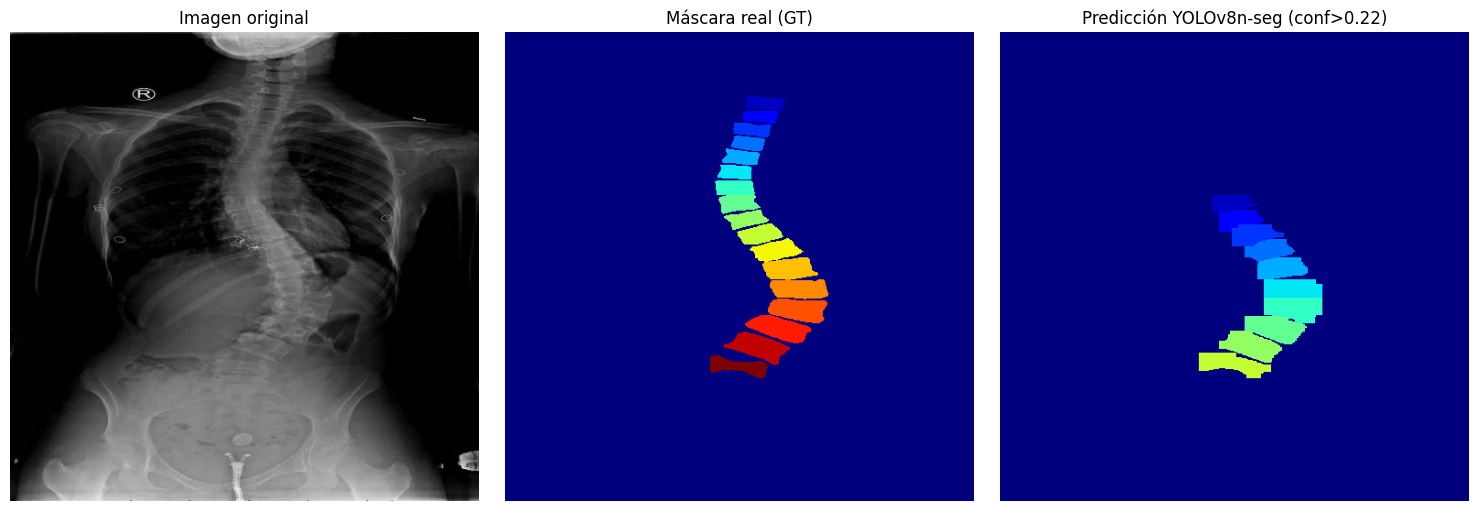

Figura guardada: comparacion_segmentacion.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

# ── Seleccionar una imagen del test set ──────────────────────────────
test_row      = test_df.sample(1, random_state=42).iloc[0]
test_img_path  = test_row['image']
test_mask_path = test_row['mask']

# ── DIAGNÓSTICO: ver los scores brutos del modelo ────────────────────
# Primero corremos con conf=0.01 (casi sin filtro) para ver qué
# puntuaciones está produciendo el modelo antes de decidir el umbral.
results_raw = best_model.predict(
    source  = test_img_path,
    imgsz   = 512,
    conf    = 0.01,   # sin filtro: ver TODOS los candidatos
    iou     = 0.7,    # NMS permisivo: vértebras se solapan verticalmente
    device  = device,
    verbose = False,
)
raw = results_raw[0]

if raw.boxes is not None and len(raw.boxes):
    scores = raw.boxes.conf.cpu().numpy()
    print(f'Detecciones con conf>0.01 : {len(scores)}')
    print(f'Score mínimo  : {scores.min():.4f}')
    print(f'Score máximo  : {scores.max():.4f}')
    print(f'Score mediano : {scores.mean():.4f}')
    # Sugerir umbral automáticamente
    CONF_AUTO = max(0.01, float(scores.mean()) * 0.5)
    print(f'\n→ Umbral sugerido automáticamente: {CONF_AUTO:.4f}')
else:
    print('Sin detecciones incluso con conf=0.01.')
    print('El modelo puede necesitar más épocas de entrenamiento.')
    CONF_AUTO = 0.01

# ── Inferencia final con umbral adaptativo ───────────────────────────
# Las vértebras se solapan verticalmente → iou alto (0.7-0.8)
# para que NMS no elimine detecciones válidas adyacentes.
results = best_model.predict(
    source  = test_img_path,
    imgsz   = 512,
    conf    = CONF_AUTO,
    iou     = 0.7,
    device  = device,
    verbose = False,
)
result = results[0]

# ── Leer imagen y máscara real ───────────────────────────────────────
img_np    = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
img_np    = cv2.resize(img_np, (512, 512))
mask_real = cv2.imread(test_mask_path, cv2.IMREAD_GRAYSCALE)
mask_real = cv2.resize(mask_real, (512, 512), interpolation=cv2.INTER_NEAREST)

# ── Construir mapa de segmentación predicho ──────────────────────────
pred_map = np.zeros((512, 512), dtype=np.uint8)

if result.masks is not None:
    masks_data = result.masks.data.cpu().numpy()         # (N, H, W)
    classes    = result.boxes.cls.cpu().numpy().astype(int)
    confs      = result.boxes.conf.cpu().numpy()

    for mask_i, cls_i in zip(masks_data, classes):
        mask_resized = cv2.resize(
            (mask_i > 0.5).astype(np.uint8),
            (512, 512), interpolation=cv2.INTER_NEAREST
        )
        pred_map[mask_resized == 1] = cls_i + 1

    print(f'\nVértebras detectadas: {len(classes)}')
    print('Clases y confianza:')
    for c, cf in zip(classes, confs):
        print(f'  {CLASS_NAMES[c]:4s}  conf={cf:.3f}')
else:
    print('\n⚠️  Sin detecciones. El modelo necesita más épocas de entrenamiento.')
    print('   Recomendaciones:')
    print('   1. Aumentar epochs a 50-100 en la Celda 5')
    print('   2. Verificar que las etiquetas .txt se generaron correctamente (Celda 3)')
    print('   3. Revisar spine_yolo/yolov8n_seg/results.csv para ver si el modelo aprendió')

# ── Visualización comparativa ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np)
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(mask_real, cmap='jet', vmin=0, vmax=N_CLASSES)
axes[1].set_title('Máscara real (GT)')
axes[1].axis('off')

axes[2].imshow(pred_map, cmap='jet', vmin=0, vmax=N_CLASSES)
axes[2].set_title(f'Predicción YOLOv8n-seg (conf>{CONF_AUTO:.2f})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('comparacion_segmentacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_segmentacion.png')


## 🎯 Celda 9: Dice Coefficient — Comparación píxel a píxel

Compara las máscaras predichas por YOLOv8n-seg contra las máscaras PNG originales (ground truth).

**Fórmula:** `Dice = 2 * |A ∩ B| / (|A| + |B|)`

- **Dice = 1.0** → segmentación perfecta
- **Dice = 0.0** → sin solapamiento
- Threshold clínico aceptable: **Dice > 0.75**

Calculando Dice: 100%|██████████| 38/38 [00:01<00:00, 34.70it/s]
/tmp/ipykernel_57/3927988992.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal_dice, escoliosis_dice], labels=['Normal', 'Escoliosis'], patch_artist=True,


       DICE COEFFICIENT — TEST SET
  Media global      : 0.7551
  Mediana           : 0.7591
  Desv. estándar    : 0.0672
  Mín               : 0.5636
  Máx               : 0.8782
  Dice > 0.75       : 20/38 imágenes

Dice por clase:
              mean     std     min     max
label                                     
Normal      0.7690  0.0841  0.5636  0.8460
Escoliosis  0.7495  0.0600  0.6026  0.8782


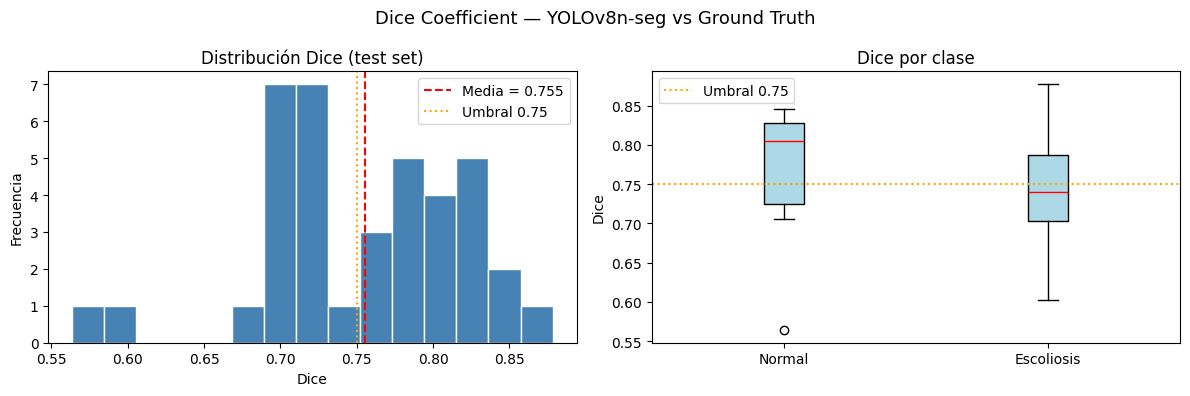

Figura guardada: dice_yolo.png

🔴 Peores 3 (Dice más bajo):
                                                                     imagen  label   dice  n_vertebras
    /kaggle/input/datasets/fedysmoreno/images/images/images/Normal/N_21.jpg      0 0.5636           10
 /kaggle/input/datasets/fedysmoreno/images/images/images/Scoliosis/S_47.jpg      1 0.6026            7
/kaggle/input/datasets/fedysmoreno/images/images/images/Scoliosis/S_195.jpg      1 0.6819           11

🟢 Mejores 3 (Dice más alto):
                                                                     imagen  label   dice  n_vertebras
/kaggle/input/datasets/fedysmoreno/images/images/images/Scoliosis/S_128.jpg      1 0.8782           17
     /kaggle/input/datasets/fedysmoreno/images/images/images/Normal/N_9.jpg      0 0.8460           17
 /kaggle/input/datasets/fedysmoreno/images/images/images/Scoliosis/S_38.jpg      1 0.8396           11


In [9]:
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# ── Parámetros (heredados del pipeline) ──────────────────────────────
CONF_DICE  = CONF_AUTO if 'CONF_AUTO' in dir() else 0.01
IOU_DICE   = 0.7
IMG_SIZE   = 512

def dice_coefficient(pred_mask, gt_mask):
    """Calcula Dice entre dos máscaras binarias (H x W, valores 0/1)."""
    pred = pred_mask.astype(bool)
    gt   = gt_mask.astype(bool)
    intersection = np.logical_and(pred, gt).sum()
    total = pred.sum() + gt.sum()
    if total == 0:
        return 1.0  # ambas vacías → acuerdo perfecto
    return 2.0 * intersection / total

def load_gt_mask(mask_path, target_size=(IMG_SIZE, IMG_SIZE)):
    """
    Carga la máscara PNG multiclase y devuelve una máscara binaria:
    1 donde hay vértebra (cualquier clase > 0), 0 en fondo.
    """
    mask = np.array(Image.open(mask_path))
    # Si es RGB, convertir a escala de grises
    if mask.ndim == 3:
        mask = mask.max(axis=2)
    binary = (mask > 0).astype(np.uint8)
    binary = cv2.resize(binary, target_size, interpolation=cv2.INTER_NEAREST)
    return binary

def yolo_pred_mask(result, target_size=(IMG_SIZE, IMG_SIZE)):
    """
    Combina todas las máscaras de instancia de YOLO en una sola
    máscara binaria (unión de todas las vértebras detectadas).
    """
    combined = np.zeros(target_size, dtype=np.uint8)
    if result.masks is None:
        return combined
    for mask_i in result.masks.data.cpu().numpy():
        m = cv2.resize(
            (mask_i > 0.5).astype(np.uint8),
            target_size, interpolation=cv2.INTER_NEAREST
        )
        combined = np.logical_or(combined, m).astype(np.uint8)
    return combined

# ── Evaluación en el test set ─────────────────────────────────────────
dice_resultados = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Calculando Dice'):
    img_path  = row['image']
    mask_path = row['mask']
    label     = row['label']

    # Predicción YOLO
    res = best_model.predict(
        source  = img_path,
        imgsz   = IMG_SIZE,
        conf    = CONF_DICE,
        iou     = IOU_DICE,
        device  = device,
        verbose = False,
    )[0]

    pred = yolo_pred_mask(res, target_size=(IMG_SIZE, IMG_SIZE))
    gt   = load_gt_mask(mask_path,  target_size=(IMG_SIZE, IMG_SIZE))
    dice = dice_coefficient(pred, gt)

    dice_resultados.append({
        'imagen'     : img_path,
        'label'      : label,
        'dice'       : round(dice, 4),
        'n_vertebras': len(res.masks.data) if res.masks else 0,
    })

dice_df = pd.DataFrame(dice_resultados)

# ── Resultados globales ───────────────────────────────────────────────
print('=' * 45)
print('       DICE COEFFICIENT — TEST SET')
print('=' * 45)
print(f'  Media global      : {dice_df["dice"].mean():.4f}')
print(f'  Mediana           : {dice_df["dice"].median():.4f}')
print(f'  Desv. estándar    : {dice_df["dice"].std():.4f}')
print(f'  Mín               : {dice_df["dice"].min():.4f}')
print(f'  Máx               : {dice_df["dice"].max():.4f}')
print(f'  Dice > 0.75       : {(dice_df["dice"] > 0.75).sum()}/{len(dice_df)} imágenes')
print('=' * 45)

print('\nDice por clase:')
print(dice_df.groupby('label')['dice'].agg(['mean','std','min','max']).rename(
    index={0: 'Normal', 1: 'Escoliosis'}
).round(4))

# ── Visualización ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dice Coefficient — YOLOv8n-seg vs Ground Truth', fontsize=13)

# Histograma
axes[0].hist(dice_df['dice'], bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(dice_df['dice'].mean(), color='red', linestyle='--', label=f'Media = {dice_df["dice"].mean():.3f}')
axes[0].axvline(0.75, color='orange', linestyle=':', label='Umbral 0.75')
axes[0].set_xlabel('Dice')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Dice (test set)')
axes[0].legend()

# Boxplot por clase
normal_dice    = dice_df[dice_df['label'] == 0]['dice']
escoliosis_dice = dice_df[dice_df['label'] == 1]['dice']
axes[1].boxplot([normal_dice, escoliosis_dice], labels=['Normal', 'Escoliosis'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red'))
axes[1].axhline(0.75, color='orange', linestyle=':', label='Umbral 0.75')
axes[1].set_ylabel('Dice')
axes[1].set_title('Dice por clase')
axes[1].legend()

plt.tight_layout()
plt.savefig('dice_yolo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: dice_yolo.png')

# ── Top 3 peores y mejores ────────────────────────────────────────────
print('\n🔴 Peores 3 (Dice más bajo):')
print(dice_df.nsmallest(3, 'dice')[['imagen','label','dice','n_vertebras']].to_string(index=False))
print('\n🟢 Mejores 3 (Dice más alto):')
print(dice_df.nlargest(3, 'dice')[['imagen','label','dice','n_vertebras']].to_string(index=False))

## 🔍 Celda 10: Exploración anotaciones T1–T8

Analiza cuántas imágenes tienen vértebras T1–T8 anotadas y su posición vertical.

Explorando máscaras: 100%|██████████| 248/248 [00:07<00:00, 32.69it/s]


   EXPLORACIÓN ANOTACIONES T1–T8
  Total imágenes         : 248
  Con T1–T8 anotadas     : 248 (100.0%)
  Sin T1–T8              : 0 (0.0%)
  Vértebras/imagen media : 18.7
  T1–T8/imagen media     : 8.0
  Top Y norm media       : 0.119  (0=arriba, 1=abajo)

Distribución de vértebras T1–T8 por imagen:
n_t1_t8
8    248


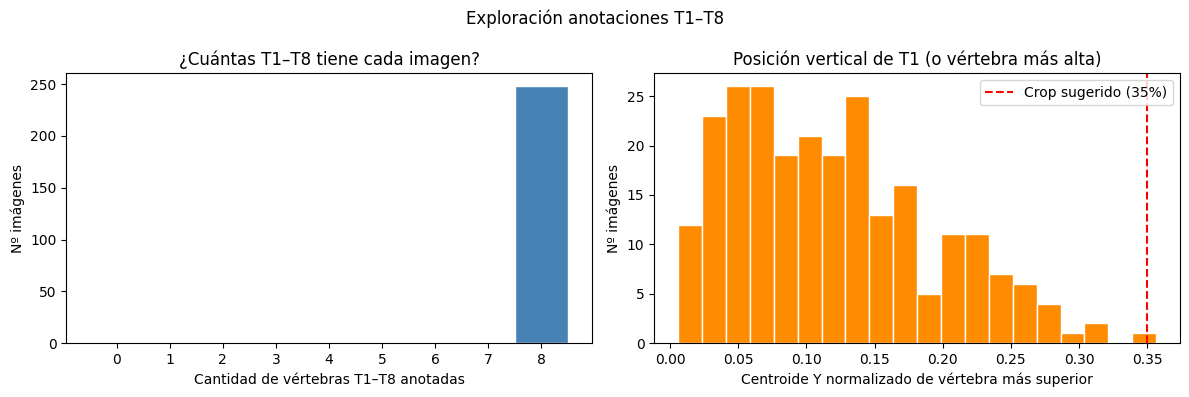

Figura guardada: exploracion_t1_t8.png

→ Imágenes disponibles para modelo especializado T1–T8: 248


In [11]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

IMG_SIZE = 512

# Mapeo: los primeros 12 valores únicos > 0 son T1–T12, los siguientes 5 son L1–L5
# (ordenados por centroide Y, de superior a inferior)
VERTEBRA_LABELS = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
N_VERTEBRAS     = len(VERTEBRA_LABELS)  # 17
THORACIC_UPPER  = 8   # T1–T8 son las que nos interesan

def get_vertebra_info(mask_path, size=IMG_SIZE):
    """Retorna lista de (label, centroid_y_norm, area_px) por vértebra."""
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3: mask = mask[:, :, 0]
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    info = []
    for val in np.unique(mask):
        if val == 0: continue
        m  = (mask == val).astype(np.uint8)
        ys, _ = np.where(m)
        cy = float(ys.mean()) / size  # normalizado 0–1
        info.append((cy, m.sum()))
    info.sort(key=lambda x: x[0])  # superior → inferior
    result = []
    for idx, (cy, area) in enumerate(info):
        label = VERTEBRA_LABELS[idx] if idx < N_VERTEBRAS else f'V{idx+1}'
        result.append({'label': label, 'idx': idx, 'centroid_y_norm': cy, 'area_px': area})
    return result

# ── Explorar todo el dataset (train + val + test) ─────────────────────
# Usar df completo antes del split, o concatenar:
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

stats = []
for _, row in tqdm(full_df.iterrows(), total=len(full_df), desc='Explorando máscaras'):
    info = get_vertebra_info(row['mask'])
    n_total   = len(info)
    n_t1_t8   = sum(1 for v in info if v['idx'] < THORACIC_UPPER)
    has_t1_t8 = n_t1_t8 > 0
    # Centroide Y más superior (T1 si existe)
    top_y = info[0]['centroid_y_norm'] if info else None
    stats.append({
        'image'    : row['image'],
        'mask'     : row['mask'],
        'label'    : row['label'],
        'n_total'  : n_total,
        'n_t1_t8'  : n_t1_t8,
        'has_t1_t8': has_t1_t8,
        'top_y_norm': top_y,
    })

stats_df = pd.DataFrame(stats)

# ── Reporte ───────────────────────────────────────────────────────────
total      = len(stats_df)
con_t1_t8  = stats_df['has_t1_t8'].sum()
sin_t1_t8  = total - con_t1_t8

print('='*50)
print('   EXPLORACIÓN ANOTACIONES T1–T8')
print('='*50)
print(f'  Total imágenes         : {total}')
print(f'  Con T1–T8 anotadas     : {con_t1_t8} ({con_t1_t8/total*100:.1f}%)')
print(f'  Sin T1–T8              : {sin_t1_t8} ({sin_t1_t8/total*100:.1f}%)')
print(f'  Vértebras/imagen media : {stats_df["n_total"].mean():.1f}')
print(f'  T1–T8/imagen media     : {stats_df["n_t1_t8"].mean():.1f}')
print(f'  Top Y norm media       : {stats_df["top_y_norm"].mean():.3f}  (0=arriba, 1=abajo)')
print('='*50)

# Distribución de n_t1_t8
print('\nDistribución de vértebras T1–T8 por imagen:')
print(stats_df['n_t1_t8'].value_counts().sort_index().to_string())

# ── Gráfico: distribución del centroide Y más superior ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Exploración anotaciones T1–T8', fontsize=12)

axes[0].hist(stats_df['n_t1_t8'], bins=range(0, THORACIC_UPPER + 2),
             color='steelblue', edgecolor='white', align='left')
axes[0].set_xlabel('Cantidad de vértebras T1–T8 anotadas')
axes[0].set_ylabel('Nº imágenes')
axes[0].set_title('¿Cuántas T1–T8 tiene cada imagen?')
axes[0].set_xticks(range(0, THORACIC_UPPER + 1))

axes[1].hist(stats_df['top_y_norm'].dropna(), bins=20,
             color='darkorange', edgecolor='white')
axes[1].axvline(0.35, color='red', linestyle='--', label='Crop sugerido (35%)')
axes[1].set_xlabel('Centroide Y normalizado de vértebra más superior')
axes[1].set_ylabel('Nº imágenes')
axes[1].set_title('Posición vertical de T1 (o vértebra más alta)')
axes[1].legend()

plt.tight_layout()
plt.savefig('exploracion_t1_t8.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: exploracion_t1_t8.png')
print(f'\n→ Imágenes disponibles para modelo especializado T1–T8: {con_t1_t8}')

## ✂️ Celda 11: Generar dataset crop T1–T8

Recorta el 50% superior de cada imagen para crear el dataset del modelo especializado.

In [12]:
import os
import shutil
import numpy as np
import cv2
import yaml
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

IMG_SIZE   = 512
CROP_RATIO = 0.50   # usar el 42% superior (ajustar según gráfica 18a)
CROP_H     = int(IMG_SIZE * CROP_RATIO)  # píxeles del crop

CROP_DIR = '/kaggle/working/spine_crop_t1t8'
for split in ['train', 'val', 'test']:
    os.makedirs(f'{CROP_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{CROP_DIR}/masks/{split}',  exist_ok=True)
    os.makedirs(f'{CROP_DIR}/labels/{split}', exist_ok=True)

def get_t1_t8_mask(mask_path, size=IMG_SIZE, n_upper=8):
    """
    Retorna máscara binaria solo con las n_upper vértebras superiores (T1–T8).
    """
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3: mask = mask[:, :, 0]
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

    instances = []
    for val in np.unique(mask):
        if val == 0: continue
        m  = (mask == val).astype(np.uint8)
        ys, _ = np.where(m)
        cy = float(ys.mean()) if len(ys) > 0 else 0.0
        instances.append((cy, val, m))
    instances.sort(key=lambda x: x[0])  # superior → inferior

    # Tomar solo las n_upper vértebras más superiores
    upper = instances[:n_upper]
    result = np.zeros((size, size), dtype=np.uint8)
    for idx, (_, _, m) in enumerate(upper):
        result[m > 0] = idx + 1  # reasignar IDs 1..8
    return result, len(upper)

def mask_to_yolo_seg(mask, crop_h, img_w=IMG_SIZE):
    """
    Convierte máscara multiclase (dentro del crop) a formato YOLO segmentación.
    Retorna lista de líneas de texto para el archivo .txt.
    """
    lines = []
    for val in np.unique(mask):
        if val == 0: continue
        m = (mask == val).astype(np.uint8)
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours: continue
        cnt = max(contours, key=cv2.contourArea)
        if len(cnt) < 3: continue
        # Normalizar coordenadas al tamaño del crop
        pts = cnt.reshape(-1, 2).astype(float)
        pts[:, 0] /= img_w    # x normalizado
        pts[:, 1] /= crop_h   # y normalizado al crop
        coords = ' '.join([f'{x:.6f} {y:.6f}' for x, y in pts])
        class_id = int(val) - 1  # 0-based
        lines.append(f'{class_id} {coords}')
    return lines

# ── Filtrar solo imágenes con T1–T8 ──────────────────────────────────
crop_df = stats_df.copy().reset_index(drop=True)
print(f'Imágenes con T1–T8: {len(crop_df)}')

# Split estratificado (misma proporción Normal/Escoliosis)
train_c, tmp_c = train_test_split(crop_df, test_size=0.30,
                                   stratify=crop_df['label'], random_state=42)
val_c,  test_c = train_test_split(tmp_c,   test_size=0.50,
                                   stratify=tmp_c['label'],   random_state=42)

split_map = {}
for df_s, name in [(train_c,'train'),(val_c,'val'),(test_c,'test')]:
    for _, r in df_s.iterrows():
        split_map[r['image']] = name

print(f'Train: {len(train_c)}  Val: {len(val_c)}  Test: {len(test_c)}')

# ── Generar crops ─────────────────────────────────────────────────────
n_ok, n_skip = 0, 0
for _, row in tqdm(crop_df.iterrows(), total=len(crop_df), desc='Generando crops'):
    split = split_map[row['image']]
    fname = os.path.splitext(os.path.basename(row['image']))[0]

    # Imagen
    img = cv2.imread(row['image'], cv2.IMREAD_GRAYSCALE)
    if img is None: n_skip += 1; continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_crop = img[:CROP_H, :]  # crop superior
    img_crop_resized = cv2.resize(img_crop, (IMG_SIZE, IMG_SIZE))  # escalar a 512 para YOLO

    # Máscara T1–T8
    mask_t1t8, n_found = get_t1_t8_mask(row['mask'])
    if n_found == 0: n_skip += 1; continue
    mask_crop = mask_t1t8[:CROP_H, :]  # mismo crop
    mask_crop_resized = cv2.resize(mask_crop, (IMG_SIZE, IMG_SIZE),
                                    interpolation=cv2.INTER_NEAREST)

    # Labels YOLO
    yolo_lines = mask_to_yolo_seg(mask_crop, CROP_H)
    if not yolo_lines: n_skip += 1; continue

    # Guardar
    cv2.imwrite(f'{CROP_DIR}/images/{split}/{fname}_crop.jpg', img_crop_resized)
    cv2.imwrite(f'{CROP_DIR}/masks/{split}/{fname}_crop.png',  mask_crop_resized)
    with open(f'{CROP_DIR}/labels/{split}/{fname}_crop.txt', 'w') as f:
        f.write('\n'.join(yolo_lines))
    n_ok += 1

print(f'\nCrops generados : {n_ok}')
print(f'Saltados        : {n_skip}')

# ── YAML para modelo especializado ───────────────────────────────────
yaml_content = {
    'path' : CROP_DIR,
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : 8,
    'names': {i: f'T{i+1}' for i in range(8)}  # T1..T8
}
yaml_path = f'{CROP_DIR}/spine_t1t8.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)
print(f'YAML guardado: {yaml_path}')
print(yaml_content)

Imágenes con T1–T8: 248
Train: 173  Val: 37  Test: 38


Generando crops: 100%|██████████| 248/248 [00:09<00:00, 25.06it/s]


Crops generados : 248
Saltados        : 0
YAML guardado: /kaggle/working/spine_crop_t1t8/spine_t1t8.yaml
{'path': '/kaggle/working/spine_crop_t1t8', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 8, 'names': {0: 'T1', 1: 'T2', 2: 'T3', 3: 'T4', 4: 'T5', 5: 'T6', 6: 'T7', 7: 'T8'}}


## 🏋️ Celda 12: Entrenar modelo especializado T1–T8

Entrena YOLOv8s-seg solo sobre la región torácica superior (T1–T8) con augmentations agresivos.

In [13]:
from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_t1t8 = YOLO('yolov8s-seg.pt')

results_t1t8 = model_t1t8.train(
    data    = f'{CROP_DIR}/spine_t1t8.yaml',
    epochs  = 150,           # más épocas: dataset más pequeño
    imgsz   = 512,
    batch   = 8,
    device  = device,
    patience= 30,
    name    = 'yolov8s_seg_t1t8',
    project = 'spine_yolo',
    exist_ok= True,
    val     = True,
    save    = True,
    plots   = True,

    # Augmentations agresivos (dataset pequeño → necesita más variación)
    degrees     = 15,
    scale       = 0.5,
    mosaic      = 1.0,
    close_mosaic= 30,
    copy_paste  = 0.5,       # más agresivo que el modelo completo
    mixup       = 0.15,
    flipud      = 0.0,       # NO voltear verticalmente
    fliplr      = 0.5,
    hsv_h       = 0.0,
    hsv_s       = 0.0,
    hsv_v       = 0.4,       # más variación de brillo
    translate   = 0.15,
    shear       = 3.0,
    perspective = 0.0003,

    optimizer    = 'AdamW',
    lr0          = 0.001,
    lrf          = 0.01,
    weight_decay = 0.0005,
    warmup_epochs= 5,
)

print('\n✅ Modelo T1–T8 entrenado')
print('Mejor modelo: spine_yolo/yolov8s_seg_t1t8/weights/best.pt')

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=30, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/spine_crop_t1t8/spine_t1t8.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_seg_t1t8, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, ove

## 🔀 Celda 13: Ensemble — Modelo completo + Especializado T1–T8

- **Región superior (0–50%)** → modelo especializado T1–T8
- **Región inferior (50–100%)** → modelo completo

Combina ambas predicciones y calcula Dice por vértebra.

In [16]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

IMG_SIZE   = 512
CROP_RATIO = 0.42
CROP_H     = int(IMG_SIZE * CROP_RATIO)

VERTEBRA_LABELS = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
N_VERTEBRAS     = len(VERTEBRA_LABELS)
THORACIC_N      = 12

# ── Cargar ambos modelos ──────────────────────────────────────────────
model_full  = YOLO('/kaggle/working/runs/segment/spine_yolo/yolov8s_seg_768/weights/best.pt')   # modelo completo
model_t1t8  = YOLO('/kaggle/working/runs/segment/spine_yolo/yolov8s_seg_t1t8/weights/best.pt')  # especializado
CONF_E      = CONF_AUTO if 'CONF_AUTO' in dir() else 0.01
device      = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print('Ambos modelos cargados ✅')

# ── Helpers ───────────────────────────────────────────────────────────
def yolo_instances(result, size=IMG_SIZE):
    """Extrae lista de (centroid_y, binary_mask) de un resultado YOLO."""
    instances = []
    if result.masks is None: return instances
    for m in result.masks.data.cpu().numpy():
        binary = cv2.resize((m > 0.5).astype(np.uint8), (size, size),
                            interpolation=cv2.INTER_NEAREST)
        ys, _ = np.where(binary)
        cy = float(ys.mean()) if len(ys) > 0 else 0.0
        instances.append((cy, binary))
    instances.sort(key=lambda x: x[0])
    return instances

def ensemble_instances(img_path, size=IMG_SIZE, crop_h=CROP_H):
    """
    Combina predicciones de ambos modelos:
    - Modelo T1–T8: predice sobre crop superior escalado a 512
      → las máscaras se mapean de vuelta a coordenadas originales
    - Modelo completo: predice sobre imagen completa
      → se usan solo instancias con centroide Y > crop_h (región inferior)
    """
    # 1. Crop superior → modelo especializado
    img_full = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_full = cv2.resize(img_full, (size, size))
    img_crop = img_full[:crop_h, :]
    img_crop_512 = cv2.resize(img_crop, (size, size))
    crop_tmp = '/kaggle/working/_tmp_crop.jpg'
    cv2.imwrite(crop_tmp, img_crop_512)

    res_t1t8 = model_t1t8.predict(
        source=crop_tmp, imgsz=size, conf=CONF_E,
        iou=0.7, device=device, verbose=False
    )[0]

    # Mapear máscaras del crop de vuelta a coordenadas originales (512×512)
    upper_instances = []
    if res_t1t8.masks is not None:
        for m in res_t1t8.masks.data.cpu().numpy():
            m_crop = cv2.resize((m > 0.5).astype(np.uint8), (size, size),
                                interpolation=cv2.INTER_NEAREST)
            # Escalar Y de vuelta: crop_h/size ratio
            m_full = np.zeros((size, size), dtype=np.uint8)
            m_rescaled = cv2.resize(m_crop, (size, crop_h),
                                    interpolation=cv2.INTER_NEAREST)
            m_full[:crop_h, :] = m_rescaled
            ys, _ = np.where(m_full)
            cy = float(ys.mean()) if len(ys) > 0 else 0.0
            upper_instances.append((cy, m_full))
    upper_instances.sort(key=lambda x: x[0])

    # 2. Imagen completa → modelo general (solo región inferior)
    res_full = model_full.predict(
        source=img_path, imgsz=size, conf=CONF_E,
        iou=0.7, device=device, verbose=False
    )[0]
    lower_instances = []
    for cy, m in yolo_instances(res_full):
        if cy >= crop_h:   # solo vértebras debajo del crop
            lower_instances.append((cy, m))

    # 3. Combinar: upper (T1–T8) + lower (T9–L5)
    all_instances = upper_instances + lower_instances
    all_instances.sort(key=lambda x: x[0])
    return all_instances

def extract_gt_instances(mask_path, size=IMG_SIZE):
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3: mask = mask[:, :, 0]
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    instances = []
    for val in np.unique(mask):
        if val == 0: continue
        m  = (mask == val).astype(np.uint8)
        ys, _ = np.where(m)
        instances.append((float(ys.mean()) if len(ys) > 0 else 0.0, m))
    instances.sort(key=lambda x: x[0])
    return instances[:N_VERTEBRAS]

def iou_score(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0

def dice_pair(a, b):
    inter = np.logical_and(a, b).sum()
    total = a.sum() + b.sum()
    return 2.0 * inter / total if total > 0 else 1.0

def greedy_match(gt_list, pred_list, iou_thresh=0.1):
    matched_preds = set()
    results = []
    for gt_idx, (_, gt_mask) in enumerate(gt_list):
        label = VERTEBRA_LABELS[gt_idx] if gt_idx < N_VERTEBRAS else f'V{gt_idx+1}'
        best_iou, best_pidx, best_dice = 0.0, -1, 0.0
        for p_idx, (_, pred_mask) in enumerate(pred_list):
            if p_idx in matched_preds: continue
            score = iou_score(gt_mask, pred_mask)
            if score > best_iou:
                best_iou, best_pidx = score, p_idx
                best_dice = dice_pair(gt_mask, pred_mask)
        if best_pidx >= 0 and best_iou >= iou_thresh:
            matched_preds.add(best_pidx)
            results.append({'vertebra_idx': gt_idx, 'label': label,
                            'dice': best_dice, 'matched': True})
        else:
            results.append({'vertebra_idx': gt_idx, 'label': label,
                            'dice': 0.0, 'matched': False})
    return results

# ── Evaluación ensemble en test set ──────────────────────────────────
ensemble_vertebra = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Ensemble inference'):
    gt_insts   = extract_gt_instances(row['mask'])
    if len(gt_insts) == 0: continue
    pred_insts = ensemble_instances(row['image'])
    for m in greedy_match(gt_insts, pred_insts):
        m['label_cls'] = row['label']
        ensemble_vertebra.append(m)

ens_df = pd.DataFrame(ensemble_vertebra)

# ── Tabla comparativa por vértebra ───────────────────────────────────
# Solo mostramos resultados del ensemble (vdf eliminado en versión limpia)
ens_sum = ens_df.groupby(['vertebra_idx','label'])['dice'].mean().reset_index()
ens_sum = ens_sum.sort_values('vertebra_idx')

print('='*55)
print('   DICE POR VÉRTEBRA — Ensemble (T1–T8 + Completo)')
print('='*55)
print(f'{"Vértebra":10} {"Dice ensemble":>14}')
print('-'*55)
for _, r in ens_sum.iterrows():
    lbl   = VERTEBRA_LABELS[int(r['vertebra_idx'])] if int(r['vertebra_idx']) < N_VERTEBRAS else '?'
    flag  = '✅' if r['dice'] >= 0.75 else '⚠️'
    print(f'{lbl:10} {r["dice"]:>14.4f} {flag}')
print('='*55)
print(f'{"MEDIA":10} {ens_sum["dice"].mean():>14.4f}')



Ambos modelos cargados ✅


Ensemble inference: 100%|██████████| 38/38 [00:08<00:00,  4.65it/s]

   DICE POR VÉRTEBRA — Ensemble (T1–T8 + Completo)
Vértebra    Dice ensemble
-------------------------------------------------------
T1                 0.5162 ⚠️
T2                 0.6816 ⚠️
T3                 0.7409 ⚠️
T4                 0.7392 ⚠️
T5                 0.7504 ✅
T6                 0.7832 ✅
T7                 0.7729 ✅
T8                 0.7300 ⚠️
T9                 0.6959 ⚠️
T10                0.7399 ⚠️
T11                0.7457 ⚠️
T12                0.7381 ⚠️
L1                 0.7840 ✅
L2                 0.8242 ✅
L3                 0.8527 ✅
L4                 0.8195 ✅
L5                 0.7170 ⚠️
MEDIA              0.7430


## 🦴 Celda 14: Dice por vértebra — T1–T12 · L1–L5 (Ensemble)

Dice medio ± std y % detección por posición vertebral usando el ensemble.

Dice medio global (ensemble): 0.7430
Vértebra    Media      Std  Detectadas  Total     % Det
      T1 0.516225 0.447042          22     38 57.894737
      T2 0.681584 0.386208          29     38 76.315789
      T3 0.740925 0.327271          32     38 84.210526
      T4 0.739182 0.327231          32     38 84.210526
      T5 0.750412 0.331661          32     38 84.210526
      T6 0.783168 0.278140          34     38 89.473684
      T7 0.772918 0.312182          33     38 86.842105
      T8 0.730047 0.333793          32     38 84.210526
      T9 0.695851 0.329904          32     38 84.210526
     T10 0.739941 0.286332          34     38 89.473684
     T11 0.745698 0.301139          33     38 86.842105
     T12 0.738084 0.295978          33     38 86.842105
      L1 0.784022 0.238975          35     38 92.105263
      L2 0.824190 0.166583          37     38 97.368421
      L3 0.852702 0.148475          37     38 97.368421
      L4 0.819451 0.202775          35     37 94.594595
      L5 0.

/tmp/ipykernel_57/1015435069.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap('RdYlGn')


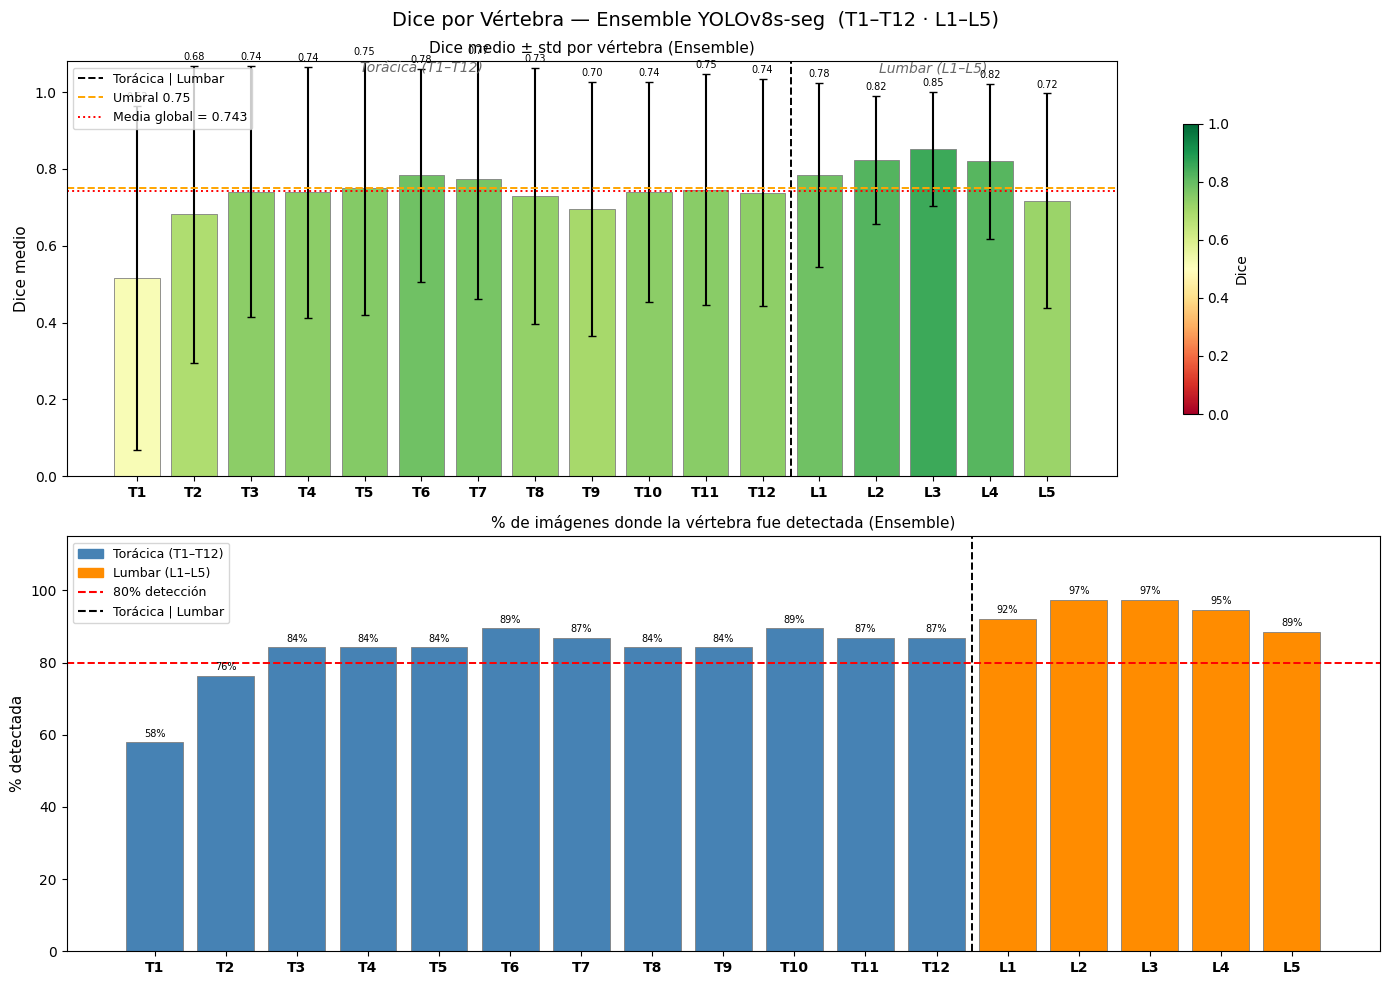

Figura guardada: ensemble_dice_por_vertebra_final.png


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

VERTEBRA_LABELS = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
N_VERTEBRAS     = len(VERTEBRA_LABELS)  # 17
THORACIC_N      = 12

# ens_df viene de la Celda 18d
summary = ens_df.groupby(['vertebra_idx', 'label']).agg(
    dice_mean = ('dice', 'mean'),
    dice_std  = ('dice', 'std'),
    n_matched = ('matched', 'sum'),
    n_total   = ('matched', 'count'),
).reset_index().sort_values('vertebra_idx')
summary['pct_matched'] = summary['n_matched'] / summary['n_total'] * 100
summary['label_name']  = summary['vertebra_idx'].apply(
    lambda i: VERTEBRA_LABELS[int(i)] if int(i) < N_VERTEBRAS else f'V{int(i)+1}'
)

print(f'Dice medio global (ensemble): {ens_df["dice"].mean():.4f}')
print(summary[['label_name','dice_mean','dice_std','n_matched','n_total','pct_matched']]
      .rename(columns={'label_name':'Vértebra','dice_mean':'Media','dice_std':'Std',
                       'n_matched':'Detectadas','n_total':'Total','pct_matched':'% Det'})
      .to_string(index=False))

# ── Gráfico ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Dice por Vértebra — Ensemble YOLOv8s-seg  (T1–T12 · L1–L5)', fontsize=14)

x      = np.arange(len(summary))
labels = summary['label_name'].tolist()
cmap   = cm.get_cmap('RdYlGn')
colors = [cmap(v) for v in summary['dice_mean']]

# --- Panel 1: Dice medio ± std ---
axes[0].bar(x, summary['dice_mean'],
            yerr=summary['dice_std'].fillna(0),
            color=colors, edgecolor='gray', capsize=3, linewidth=0.6)
axes[0].axvline(THORACIC_N - 0.5, color='black', linestyle='--',
                linewidth=1.4, label='Torácica | Lumbar')
axes[0].axhline(0.75, color='orange', linestyle='--',
                linewidth=1.4, label='Umbral 0.75')
axes[0].axhline(summary['dice_mean'].mean(), color='red', linestyle=':',
                linewidth=1.4,
                label=f'Media global = {summary["dice_mean"].mean():.3f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10, fontweight='bold')
axes[0].set_ylabel('Dice medio', fontsize=11)
axes[0].set_ylim(0, 1.08)
axes[0].set_title('Dice medio ± std por vértebra (Ensemble)', fontsize=11)
axes[0].legend(fontsize=9)

# Anotaciones de región
axes[0].text(THORACIC_N / 2 - 1, 1.05, 'Torácica (T1–T12)',
             ha='center', fontsize=10, color='dimgray', style='italic')
axes[0].text(THORACIC_N + 2, 1.05, 'Lumbar (L1–L5)',
             ha='center', fontsize=10, color='dimgray', style='italic')

# Valor encima de cada barra
for i, (val, std) in enumerate(zip(summary['dice_mean'], summary['dice_std'].fillna(0))):
    axes[0].text(i, val + std + 0.01, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=7, color='black')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=axes[0], label='Dice', shrink=0.7)

# --- Panel 2: % detección ---
bar_colors2 = ['steelblue' if i < THORACIC_N else 'darkorange'
               for i in range(len(summary))]
axes[1].bar(x, summary['pct_matched'],
            color=bar_colors2, edgecolor='gray', linewidth=0.6)
axes[1].axvline(THORACIC_N - 0.5, color='black', linestyle='--',
                linewidth=1.4, label='Torácica | Lumbar')
axes[1].axhline(80, color='red', linestyle='--',
                linewidth=1.4, label='80% detección')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10, fontweight='bold')
axes[1].set_ylabel('% detectada', fontsize=11)
axes[1].set_ylim(0, 115)
axes[1].set_title('% de imágenes donde la vértebra fue detectada (Ensemble)', fontsize=11)

# Valor encima de cada barra
for i, val in enumerate(summary['pct_matched']):
    axes[1].text(i, val + 1, f'{val:.0f}%',
                 ha='center', va='bottom', fontsize=7)

axes[1].legend(handles=[
    Patch(color='steelblue',  label='Torácica (T1–T12)'),
    Patch(color='darkorange', label='Lumbar (L1–L5)'),
    plt.Line2D([0],[0], color='red',   linestyle='--', label='80% detección'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Torácica | Lumbar'),
], fontsize=9)

plt.tight_layout()
plt.savefig('ensemble_dice_por_vertebra_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: ensemble_dice_por_vertebra_final.png')

## 🖼️ Celda 15: Comparación visual GT vs Predicción Ensemble

Grilla con las 3 peores y 3 mejores imágenes: Original · GT · Predicción · Overlay TP/FP/FN.

Dice medio ensemble (test set): 0.7908
Dice > 0.75: 29/38 imágenes


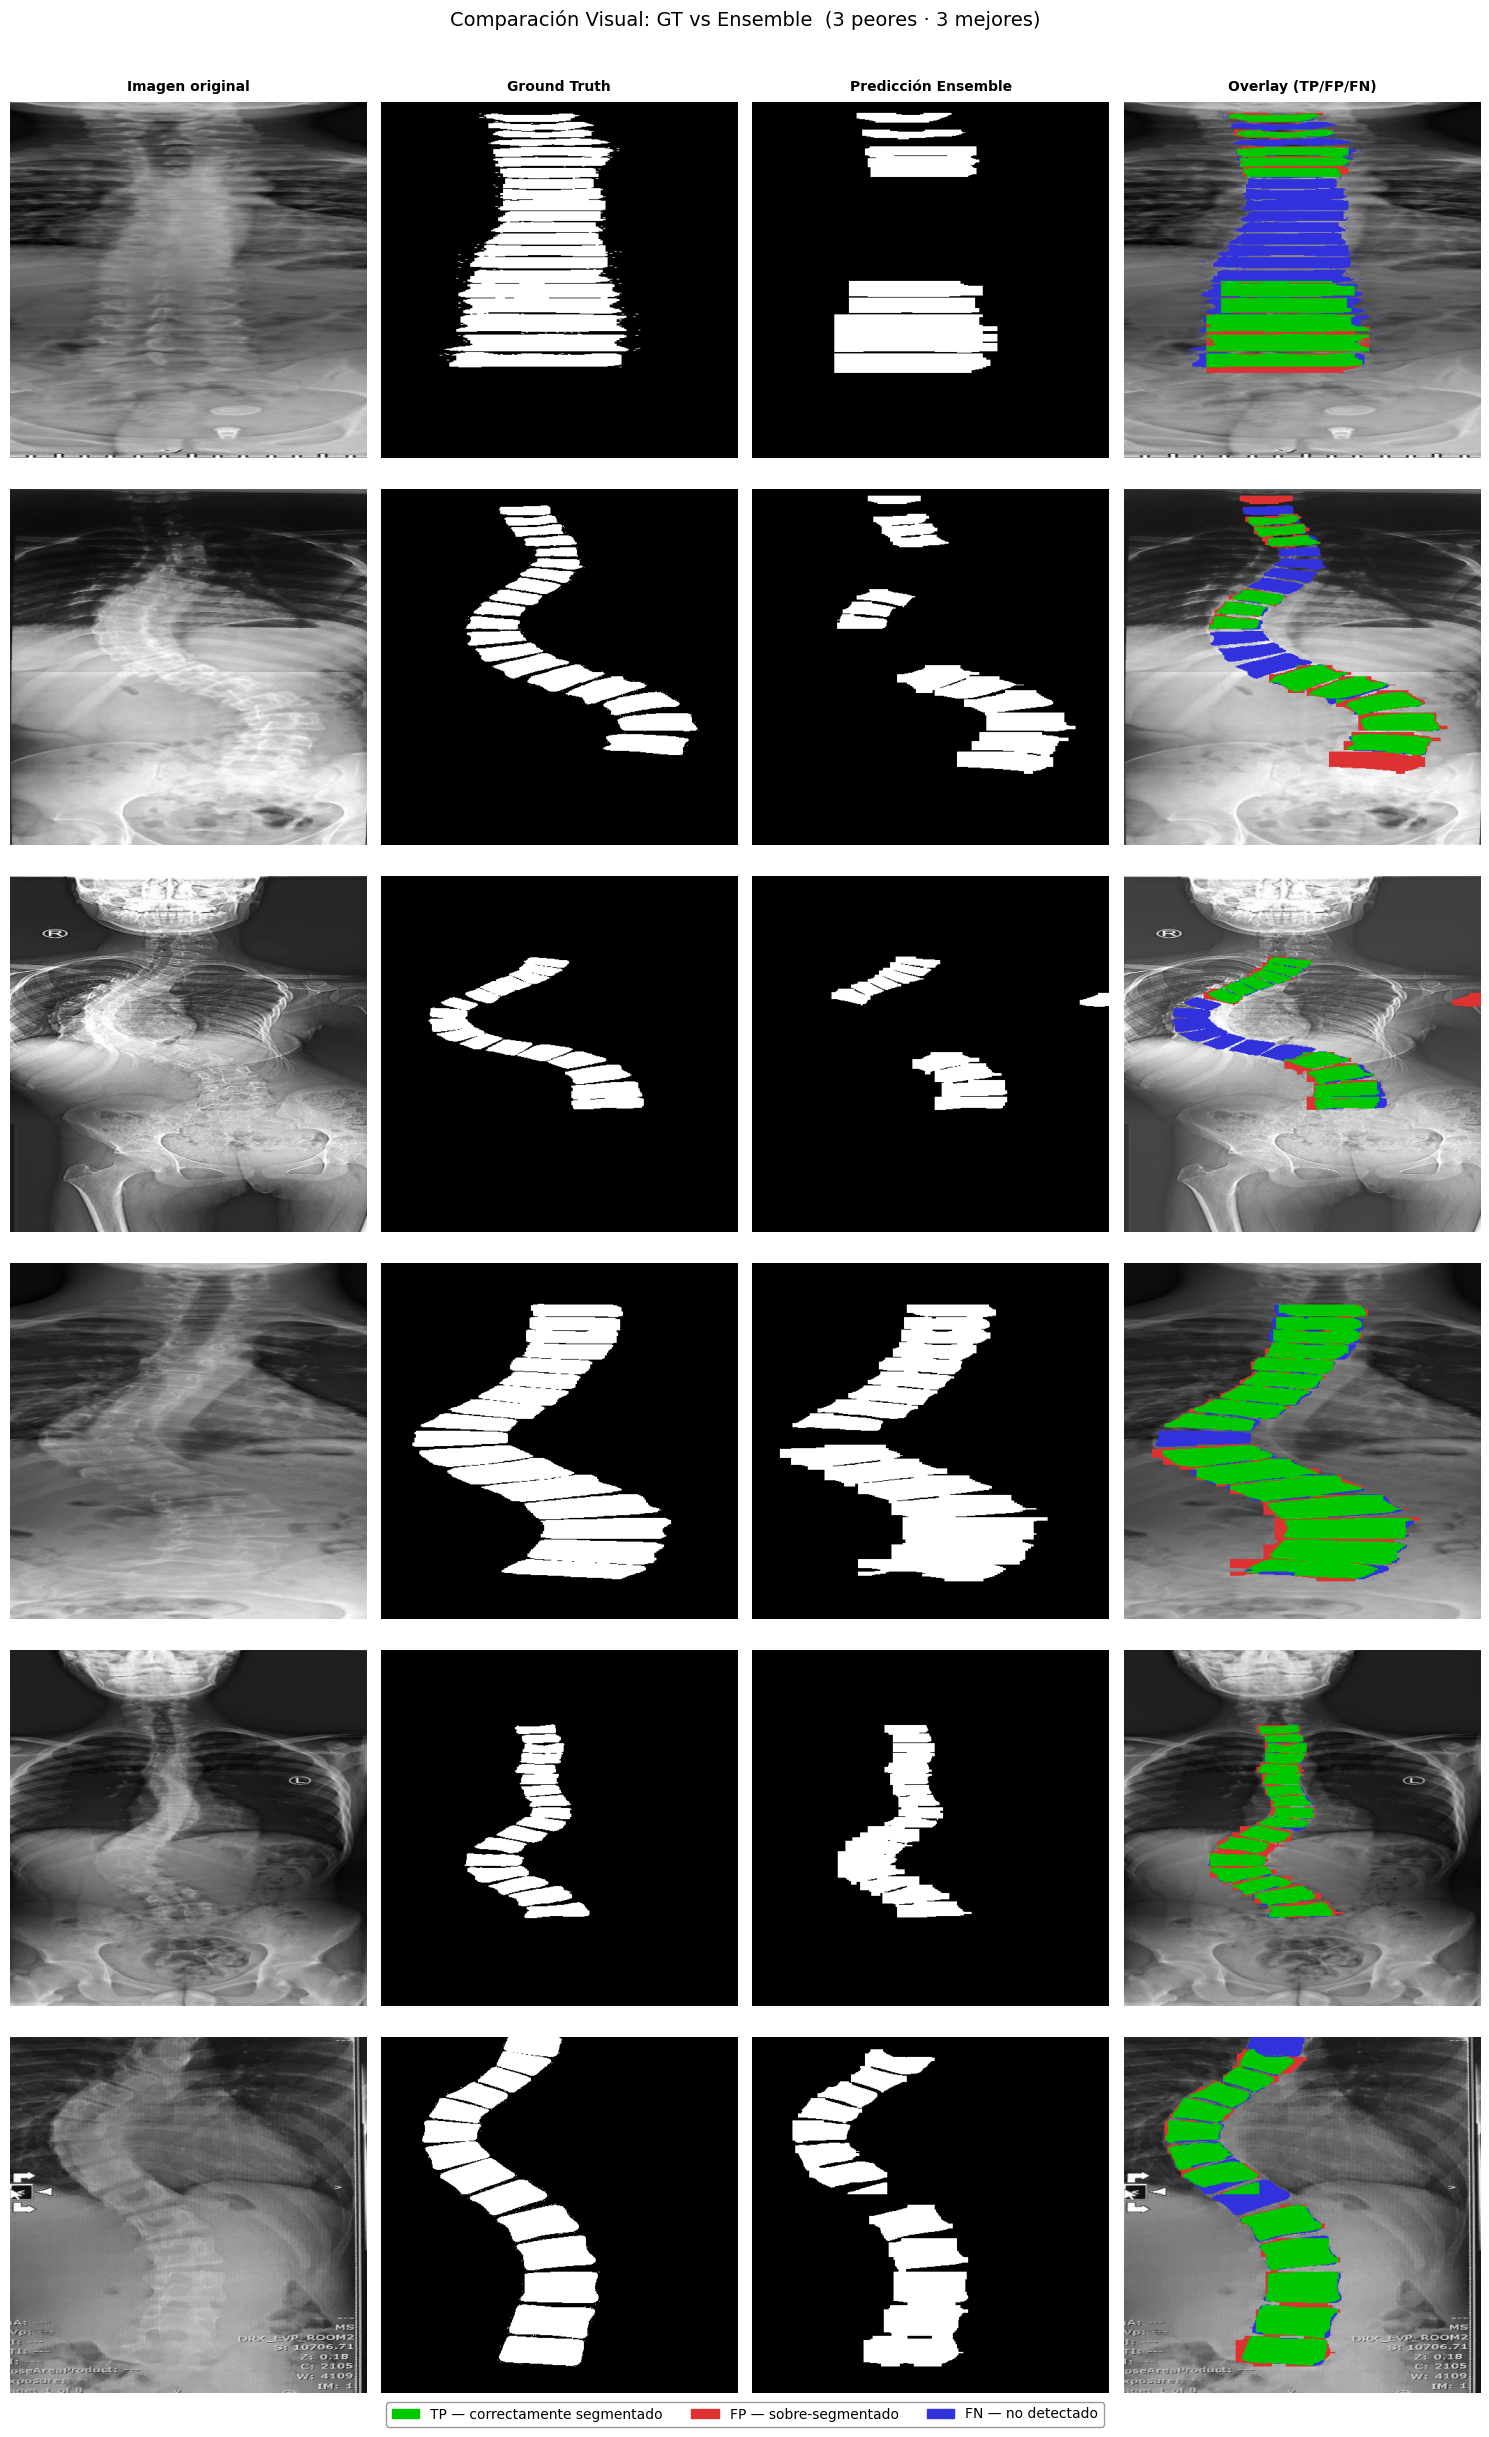

Figura guardada: ensemble_comparacion_visual.png


In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import pandas as pd

IMG_SIZE   = 512
CROP_RATIO = 0.50
CROP_H     = int(IMG_SIZE * CROP_RATIO)

# ── Helpers (reutilizados de celdas anteriores) ───────────────────────
def load_gt_binary(mask_path, size=IMG_SIZE):
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3: mask = mask.max(axis=2)
    return cv2.resize((mask > 0).astype(np.uint8), (size, size),
                      interpolation=cv2.INTER_NEAREST)

def get_ensemble_binary(img_path, size=IMG_SIZE, crop_h=CROP_H):
    """
    Obtiene máscara binaria combinada del ensemble
    (unión de todas las instancias predichas).
    """
    pred_instances = ensemble_instances(img_path, size=size, crop_h=crop_h)
    combined = np.zeros((size, size), dtype=np.uint8)
    for _, m in pred_instances:
        combined = np.logical_or(combined, m).astype(np.uint8)
    return combined

def make_overlay(img_gray, pred, gt):
    """RGB overlay: verde=TP, rojo=FP, azul=FN."""
    rgb = np.stack([img_gray] * 3, axis=-1).copy().astype(np.uint8)
    TP = np.logical_and(pred.astype(bool), gt.astype(bool))
    FP = np.logical_and(pred.astype(bool), ~gt.astype(bool))
    FN = np.logical_and(~pred.astype(bool), gt.astype(bool))
    rgb[TP] = [0,   200,  0  ]
    rgb[FP] = [220, 50,   50 ]
    rgb[FN] = [50,  50,   220]
    return rgb

def dice_score(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    total = pred.sum() + gt.sum()
    return 2.0 * inter / total if total > 0 else 1.0

# ── Calcular Dice global por imagen usando el ensemble ────────────────
img_dice_rows = []
for _, row in test_df.iterrows():
    pred = get_ensemble_binary(row['image'])
    gt   = load_gt_binary(row['mask'])
    img_dice_rows.append({
        'image': row['image'],
        'mask' : row['mask'],
        'label': row['label'],
        'dice' : round(dice_score(pred, gt), 4),
    })
img_dice_df = pd.DataFrame(img_dice_rows)

print(f'Dice medio ensemble (test set): {img_dice_df["dice"].mean():.4f}')
print(f'Dice > 0.75: {(img_dice_df["dice"] > 0.75).sum()}/{len(img_dice_df)} imágenes')

# ── Selección: 3 peores + 3 mejores ──────────────────────────────────
worst = img_dice_df.nsmallest(3, 'dice').reset_index(drop=True)
best  = img_dice_df.nlargest(3,  'dice').reset_index(drop=True)
subset      = pd.concat([worst, best], ignore_index=True)
labels_row  = ['Peor 1','Peor 2','Peor 3','Mejor 1','Mejor 2','Mejor 3']
col_titles  = ['Imagen original', 'Ground Truth', 'Predicción Ensemble', 'Overlay (TP/FP/FN)']

fig, axes = plt.subplots(6, 4, figsize=(15, 24))
fig.suptitle('Comparación Visual: GT vs Ensemble  (3 peores · 3 mejores)',
             fontsize=14, y=1.005)

for j, ct in enumerate(col_titles):
    axes[0][j].set_title(ct, fontsize=10, fontweight='bold', pad=8)

for i, row in subset.iterrows():
    img_path  = row['image']
    mask_path = row['mask']
    dice_val  = row['dice']
    clase     = 'Normal' if row['label'] == 0 else 'Escoliosis'

    img_gray = cv2.resize(
        cv2.imread(img_path, cv2.IMREAD_GRAYSCALE),
        (IMG_SIZE, IMG_SIZE)
    )
    gt      = load_gt_binary(mask_path)
    pred    = get_ensemble_binary(img_path)
    overlay = make_overlay(img_gray, pred, gt)

    row_label = f'{labels_row[i]}\nDice={dice_val:.3f}\n({clase})'
    axes[i][0].set_ylabel(row_label, fontsize=8.5, rotation=0,
                          labelpad=90, va='center')

    axes[i][0].imshow(img_gray,        cmap='gray'); axes[i][0].axis('off')
    axes[i][1].imshow(gt * 255,        cmap='gray'); axes[i][1].axis('off')
    axes[i][2].imshow(pred * 255,      cmap='gray'); axes[i][2].axis('off')
    axes[i][3].imshow(overlay);                      axes[i][3].axis('off')

# Leyenda
legend_patches = [
    mpatches.Patch(color=(0, 200/255, 0),             label='TP — correctamente segmentado'),
    mpatches.Patch(color=(220/255, 50/255, 50/255),   label='FP — sobre-segmentado'),
    mpatches.Patch(color=(50/255, 50/255, 220/255),   label='FN — no detectado'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.005),
           frameon=True, edgecolor='gray')

plt.tight_layout()
plt.savefig('ensemble_comparacion_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: ensemble_comparacion_visual.png')

## 🏷️ Celda 16: Segmentación con nombres — T1–T12 · L1–L5

Overlay con etiqueta y confianza de cada vértebra sobre la radiografía usando el ensemble.

Imagen seleccionada : /kaggle/input/datasets/fedysmoreno/images/images/images/Scoliosis/S_195.jpg
Dice de la imagen   : 0.7906
Clase               : Escoliosis
Vértebras detectadas: 21


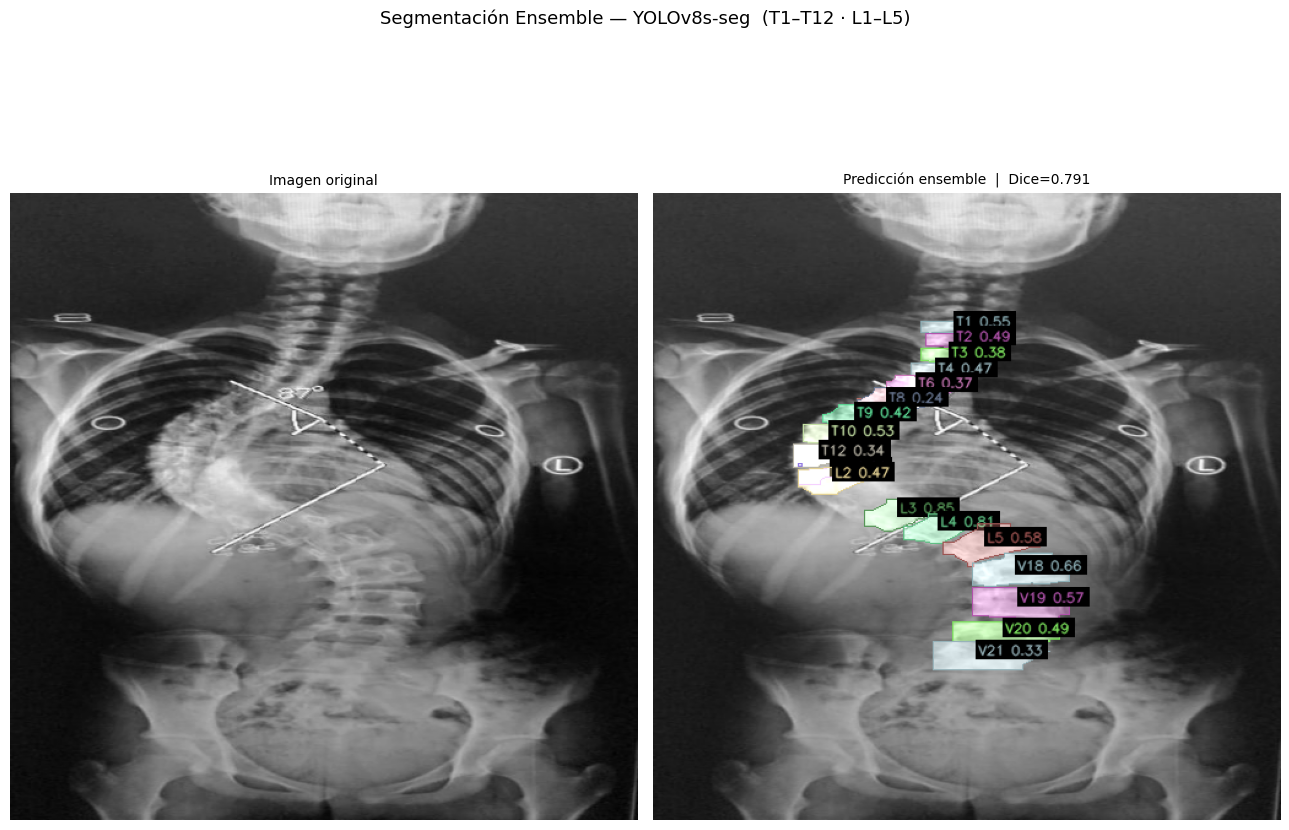

Figura guardada: segmentacion_ensemble_nombres.png

Generando overlay para las 3 mejores imágenes...


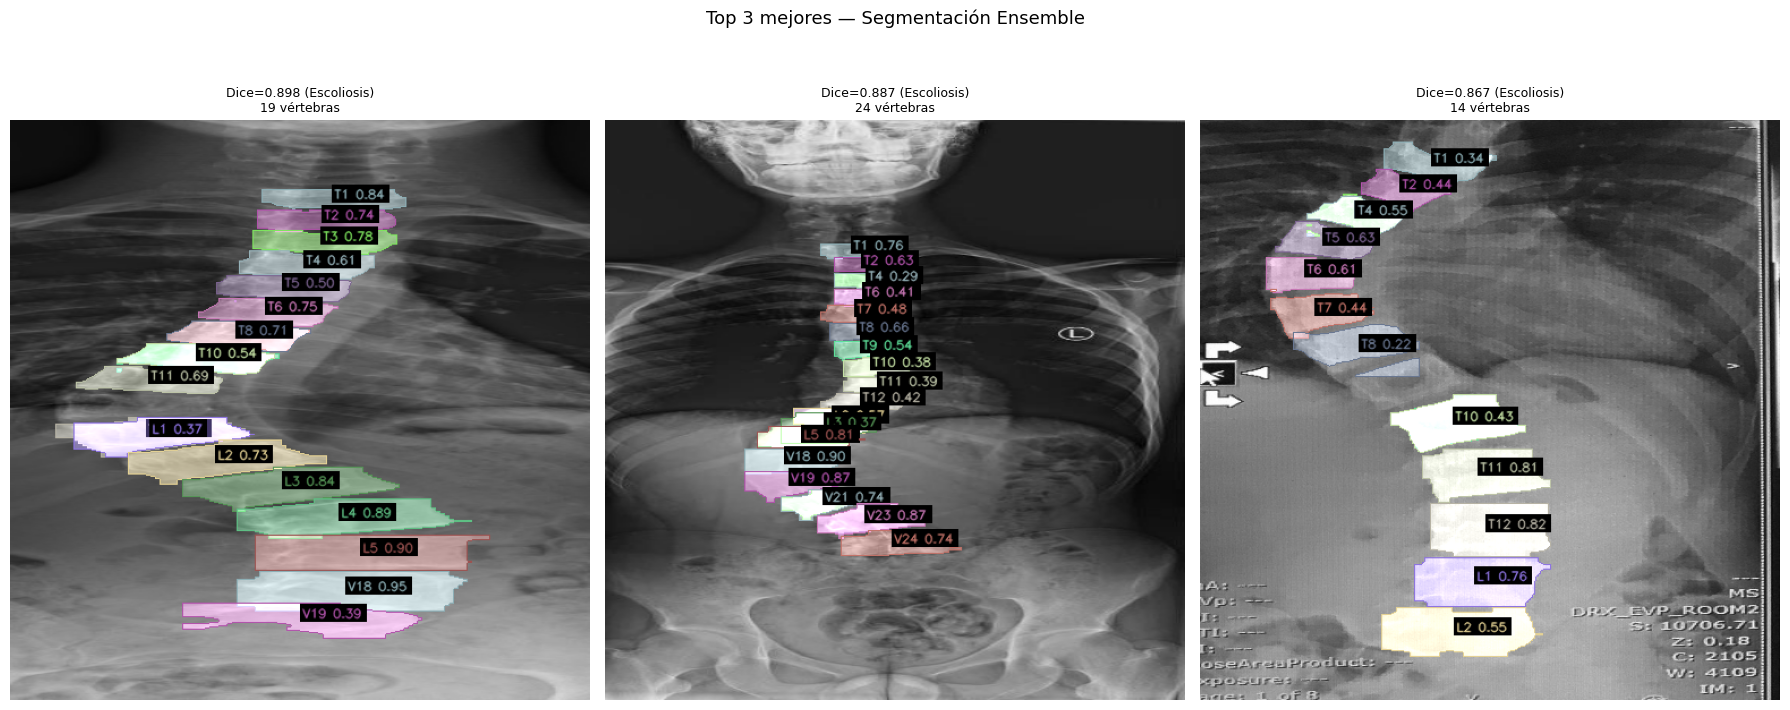

Figura guardada: segmentacion_ensemble_top3.png


In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from PIL import Image

IMG_SIZE   = 512
CROP_RATIO = 0.50
CROP_H     = int(IMG_SIZE * CROP_RATIO)

VERTEBRA_LABELS = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
N_VERTEBRAS     = len(VERTEBRA_LABELS)  # 17
CONF_E          = CONF_AUTO if 'CONF_AUTO' in dir() else 0.01
device          = 'cuda' if torch.cuda.is_available() else 'cpu'

# Colores fijos por vértebra (misma semilla → reproducible)
np.random.seed(42)
COLORS = np.random.randint(80, 230, (N_VERTEBRAS, 3), dtype=np.uint8)

def get_ensemble_instances_with_conf(img_path, size=IMG_SIZE, crop_h=CROP_H):
    """
    Retorna lista de dicts:
      { 'mask': np.array, 'centroid': (cx,cy), 'label': 'T1', 'conf': float }
    combinando ambos modelos.
    """
    instances = []

    # 1. Modelo especializado → crop superior
    img_full = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_full = cv2.resize(img_full, (size, size))
    img_crop = img_full[:crop_h, :]
    img_crop_512 = cv2.resize(img_crop, (size, size))
    crop_tmp = '/kaggle/working/_tmp_crop_overlay.jpg'
    cv2.imwrite(crop_tmp, img_crop_512)

    res_t1t8 = model_t1t8.predict(
        source=crop_tmp, imgsz=size, conf=CONF_E,
        iou=0.7, device=device, verbose=False
    )[0]

    upper = []
    if res_t1t8.masks is not None:
        for m, conf in zip(res_t1t8.masks.data.cpu().numpy(),
                           res_t1t8.boxes.conf.cpu().numpy()):
            binary_crop = cv2.resize((m > 0.5).astype(np.uint8),
                                     (size, size), interpolation=cv2.INTER_NEAREST)
            # Mapear de vuelta a coordenadas originales
            m_full = np.zeros((size, size), dtype=np.uint8)
            m_full[:crop_h, :] = cv2.resize(binary_crop, (size, crop_h),
                                             interpolation=cv2.INTER_NEAREST)
            ys, xs = np.where(m_full)
            if len(ys) == 0: continue
            upper.append((float(ys.mean()), m_full, float(conf)))
    upper.sort(key=lambda x: x[0])  # superior → inferior

    # 2. Modelo completo → solo región inferior
    res_full = model_full.predict(
        source=img_path, imgsz=size, conf=CONF_E,
        iou=0.7, device=device, verbose=False
    )[0]

    lower = []
    if res_full.masks is not None:
        for m, conf in zip(res_full.masks.data.cpu().numpy(),
                           res_full.boxes.conf.cpu().numpy()):
            binary = cv2.resize((m > 0.5).astype(np.uint8),
                                (size, size), interpolation=cv2.INTER_NEAREST)
            ys, xs = np.where(binary)
            if len(ys) == 0: continue
            cy = float(ys.mean())
            if cy >= crop_h:  # solo región inferior
                lower.append((cy, binary, float(conf)))
    lower.sort(key=lambda x: x[0])

    # 3. Combinar y asignar etiquetas por posición
    all_inst = upper + lower
    all_inst.sort(key=lambda x: x[0])

    for idx, (cy, mask, conf) in enumerate(all_inst):
        label = VERTEBRA_LABELS[idx] if idx < N_VERTEBRAS else f'V{idx+1}'
        ys, xs = np.where(mask)
        cx_c = int(np.mean(xs))
        cy_c = int(np.mean(ys))
        instances.append({
            'mask'    : mask,
            'centroid': (cx_c, cy_c),
            'label'   : label,
            'conf'    : conf,
            'idx'     : idx,
        })
    return instances

# ── Elegir imagen de ejemplo ──────────────────────────────────────────
# Usa la imagen del test set con Dice más cercano a la media (representativa)
target_dice = img_dice_df['dice'].mean()
sample_row  = img_dice_df.iloc[(img_dice_df['dice'] - target_dice).abs().argsort()[:1]].iloc[0]
SAMPLE_IMG  = sample_row['image']
print(f'Imagen seleccionada : {SAMPLE_IMG}')
print(f'Dice de la imagen   : {sample_row["dice"]:.4f}')
print(f'Clase               : {"Normal" if sample_row["label"] == 0 else "Escoliosis"}')

# ── Generar overlay ───────────────────────────────────────────────────
img_gray = cv2.resize(
    cv2.imread(SAMPLE_IMG, cv2.IMREAD_GRAYSCALE),
    (IMG_SIZE, IMG_SIZE)
)
img_bgr    = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
overlay    = img_bgr.copy()

instances = get_ensemble_instances_with_conf(SAMPLE_IMG)
print(f'Vértebras detectadas: {len(instances)}')

for inst in instances:
    mask  = inst['mask']
    cx, cy = inst['centroid']
    label  = inst['label']
    conf   = inst['conf']
    idx    = inst['idx']

    # Color único por vértebra
    color = COLORS[idx % N_VERTEBRAS].tolist()

    # Sombrear región
    colored_mask = np.zeros_like(overlay)
    colored_mask[mask == 1] = color
    overlay = cv2.addWeighted(overlay, 1.0, colored_mask, 0.45, 0)

    # Contorno
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, color, 1)

    # Etiqueta con fondo
    label_text = f'{label} {conf:.2f}'
    (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.36, 1)
    cv2.rectangle(overlay,
                  (cx - 2, cy - th - 3),
                  (cx + tw + 3, cy + 3),
                  (0, 0, 0), -1)
    cv2.putText(overlay, label_text,
                (cx, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.36,
                tuple(int(c) for c in color), 1, cv2.LINE_AA)

# ── Visualizar ────────────────────────────────────────────────────────
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 10))
fig.suptitle('Segmentación Ensemble — YOLOv8s-seg  (T1–T12 · L1–L5)', fontsize=13)

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Imagen original', fontsize=10)
axes[0].axis('off')

axes[1].imshow(overlay_rgb)
axes[1].set_title(f'Predicción ensemble  |  Dice={sample_row["dice"]:.3f}', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('segmentacion_ensemble_nombres.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: segmentacion_ensemble_nombres.png')

# ── Opcional: generar para las 3 mejores imágenes ─────────────────────
print('\nGenerando overlay para las 3 mejores imágenes...')
best3 = img_dice_df.nlargest(3, 'dice').reset_index(drop=True)

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 8))
fig2.suptitle('Top 3 mejores — Segmentación Ensemble', fontsize=13)

for i, brow in best3.iterrows():
    img_g = cv2.resize(cv2.imread(brow['image'], cv2.IMREAD_GRAYSCALE),
                       (IMG_SIZE, IMG_SIZE))
    img_b = cv2.cvtColor(img_g, cv2.COLOR_GRAY2BGR)
    ov    = img_b.copy()
    insts = get_ensemble_instances_with_conf(brow['image'])

    for inst in insts:
        mask  = inst['mask']
        cx, cy = inst['centroid']
        color  = COLORS[inst['idx'] % N_VERTEBRAS].tolist()
        cm_    = np.zeros_like(ov)
        cm_[mask == 1] = color
        ov = cv2.addWeighted(ov, 1.0, cm_, 0.45, 0)
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(ov, cnts, -1, color, 1)
        lt = f'{inst["label"]} {inst["conf"]:.2f}'
        (tw, th), _ = cv2.getTextSize(lt, cv2.FONT_HERSHEY_SIMPLEX, 0.36, 1)
        cv2.rectangle(ov, (cx-2, cy-th-3), (cx+tw+3, cy+3), (0,0,0), -1)
        cv2.putText(ov, lt, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.36,
                    tuple(int(c) for c in color), 1, cv2.LINE_AA)

    clase = 'Normal' if brow['label'] == 0 else 'Escoliosis'
    axes2[i].imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
    axes2[i].set_title(f'Dice={brow["dice"]:.3f} ({clase})\n{len(insts)} vértebras', fontsize=9)
    axes2[i].axis('off')

plt.tight_layout()
plt.savefig('segmentacion_ensemble_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: segmentacion_ensemble_top3.png')

In [20]:
import shutil
# Comprimir todos los outputs relevantes
shutil.make_archive('/kaggle/working/resultados_yolo', 'zip', 
                    '/kaggle/working/', 
                    )
print('ZIP creado: resultados_yolo.zip')

OSError: [Errno 28] No space left on device